In [1]:
# ============================================
# CELL 1: SETUP - MATHEMATICS BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=" * 60)
print("📚 MATHEMATICS BAC PREDICTION SYSTEM")
print("=" * 60)
print(f"✅ Libraries loaded successfully")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🔧 Seaborn version: {sns.__version__}")
print(f"🤖 Scikit-learn imported successfully")
print(f"🟡 SHAP version: {shap.__version__}")
print("=" * 60)
print("📖 Based on BAC 2025 Mathematics exam")
print("🎯 Target: Predict BAC score /20")
print("📐 Streams: Maths, Technical Maths, Sciences, Management, Literature")
print("🧠 Psychological factors included (math_anxiety, confidence, stress)")
print("=" * 60)
print("\n✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)")

📚 MATHEMATICS BAC PREDICTION SYSTEM
✅ Libraries loaded successfully
📊 Matplotlib version: 3.10.6
🔧 Seaborn version: 0.13.2
🤖 Scikit-learn imported successfully
🟡 SHAP version: 0.51.0
📖 Based on BAC 2025 Mathematics exam
🎯 Target: Predict BAC score /20
📐 Streams: Maths, Technical Maths, Sciences, Management, Literature
🧠 Psychological factors included (math_anxiety, confidence, stress)

✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)


In [43]:
# ============================================
# CELL 2: DATASET GENERATION - MATHEMATICS BAC (SIMPLE DIRECT METHOD)
# No fancy functions - just direct correlation control
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING MATHEMATICS BAC DATASET (SIMPLE METHOD)")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution
# ============================================

bac_scores = []
failing = np.random.uniform(6, 9.9, int(n_students * 0.10))
excellent = np.random.uniform(17, 20, int(n_students * 0.15))
average = np.random.normal(13.5, 1.5, int(n_students * 0.75))
average = np.clip(average, 10, 16.9)

bac_scores = np.concatenate([failing, excellent, average])
np.random.shuffle(bac_scores)
bac_scores = np.round(bac_scores, 1)

bac_mean = bac_scores.mean()
bac_std = bac_scores.std()
bac_scaled = (bac_scores - bac_mean) / bac_std

print(f"BAC Mean: {bac_mean:.2f}, Std: {bac_std:.2f}")
print(f"Fail: {(bac_scores < 10).sum()} ({(bac_scores < 10).sum()/n_students*100:.1f}%)")
print(f"Excellent: {(bac_scores >= 17).sum()} ({(bac_scores >= 17).sum()/n_students*100:.1f}%)")

# ============================================
# STEP 2: Generate Features with Controlled Correlation
# Formula: feature = mean + correlation * bac_scaled * std + noise * sqrt(1 - corr^2) * std
# ============================================

def make_feature(bac_scaled, target_corr, target_mean, target_std):
    """Create feature with EXACT target correlation"""
    # Signal component
    signal = target_corr * bac_scaled * target_std
    # Noise component (independent)
    noise_std = target_std * np.sqrt(1 - target_corr**2)
    noise = np.random.normal(0, noise_std, n_students)
    # Combine
    feature = target_mean + signal + noise
    return feature

# ============================================
# Generate ALL features with target correlations
# ============================================

# Academic
avg_grade = make_feature(bac_scaled, 0.65, 13.0, 2.0)
avg_grade = np.clip(avg_grade, 8, 19.5).round(1)

grade_t3 = avg_grade + np.random.normal(0.3, 0.8, n_students)
grade_t3 = np.clip(grade_t3, 8, 19.5).round(1)

grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t2 = np.clip(grade_t2, 8, 19.5).round(1)

grade_t1 = avg_grade - np.random.normal(0.5, 1.0, n_students)
grade_t1 = np.clip(grade_t1, 8, 19.5).round(1)

# Core Skills (using target correlations)
functions_analysis = make_feature(bac_scaled, 0.75, 6.5, 1.5)
functions_analysis = np.clip(functions_analysis, 2, 10).round(1)

algebra_skill = make_feature(bac_scaled, 0.55, 6.0, 1.6)
algebra_skill = np.clip(algebra_skill, 2, 10).round(1)

probability_skill = make_feature(bac_scaled, 0.50, 5.8, 1.7)
probability_skill = np.clip(probability_skill, 2, 10).round(1)

sequences_skill = make_feature(bac_scaled, 0.48, 5.8, 1.7)
sequences_skill = np.clip(sequences_skill, 2, 10).round(1)

integral_calculus = make_feature(bac_scaled, 0.50, 6.0, 1.6)
integral_calculus = np.clip(integral_calculus, 2, 10).round(1)

complex_numbers = make_feature(bac_scaled, 0.35, 5.5, 1.8)
complex_numbers = np.clip(complex_numbers, 2, 10).round(1)

proof_reasoning = make_feature(bac_scaled, 0.45, 5.8, 1.6)
proof_reasoning = np.clip(proof_reasoning, 2, 10).round(1)

geometry_skill = make_feature(bac_scaled, 0.20, 5.2, 1.9)
geometry_skill = np.clip(geometry_skill, 2, 10).round(1)

# Problem Solving
multi_step_solving = make_feature(bac_scaled, 0.50, 6.0, 1.5)
multi_step_solving = np.clip(multi_step_solving, 2, 10).round(1)

algebraic_manipulation = make_feature(bac_scaled, 0.45, 6.0, 1.6)
algebraic_manipulation = np.clip(algebraic_manipulation, 2, 10).round(1)

graph_interpretation = make_feature(bac_scaled, 0.42, 6.0, 1.6)
graph_interpretation = np.clip(graph_interpretation, 2, 10).round(1)

exam_time_management = make_feature(bac_scaled, 0.35, 5.5, 1.8)
exam_time_management = np.clip(exam_time_management, 2, 10).round(1)

# Psychological (NEGATIVE correlations)
math_anxiety = make_feature(bac_scaled, -0.50, 6.0, 2.0)
math_anxiety = np.clip(math_anxiety, 2, 10).round(1)

confidence = make_feature(bac_scaled, 0.45, 6.0, 1.8)
confidence = np.clip(confidence, 2, 10).round(1)

exam_stress = make_feature(bac_scaled, -0.40, 5.8, 2.0)
exam_stress = np.clip(exam_stress, 2, 10).round(1)

focus_concentration = make_feature(bac_scaled, 0.35, 6.0, 1.7)
focus_concentration = np.clip(focus_concentration, 2, 10).round(1)

motivation = make_feature(bac_scaled, 0.28, 6.0, 1.8)
motivation = np.clip(motivation, 2, 10).round(1)

resilience = make_feature(bac_scaled, 0.30, 5.5, 1.6)
resilience = np.clip(resilience, 2, 10).round(1)

# Practice
past_exams_solved = make_feature(bac_scaled, 0.35, 8, 5)
past_exams_solved = np.clip(past_exams_solved, 0, 30).round(0).astype(int)

exercises_per_week = make_feature(bac_scaled, 0.30, 6, 3)
exercises_per_week = np.clip(exercises_per_week, 0, 20).round(0).astype(int)

timed_exams_per_week = make_feature(bac_scaled, 0.42, 2, 1.2)
timed_exams_per_week = np.clip(timed_exams_per_week, 0, 5).round(0).astype(int)

correction_quality = make_feature(bac_scaled, 0.25, 6, 2)
correction_quality = np.clip(correction_quality, 2, 10).round(1)

study_hours = make_feature(bac_scaled, 0.25, 5, 2)
study_hours = np.clip(study_hours, 2, 15).round(1)

consistency = make_feature(bac_scaled, 0.32, 6, 2)
consistency = np.clip(consistency, 2, 10).round(1)

# Environment
teacher_quality = make_feature(bac_scaled, 0.20, 6, 1.8)
teacher_quality = np.clip(teacher_quality, 2, 10).round(1)

class_participation = make_feature(bac_scaled, 0.15, 6, 1.8)
class_participation = np.clip(class_participation, 2, 10).round(1)

tutoring = np.random.choice([0,1], n_students, p=[0.75, 0.25])
revision_strategy = np.random.choice([1,2,3], n_students, p=[0.3, 0.45, 0.25])

stream = np.random.choice(['Maths', 'Technique', 'Sciences', 'Gestion', 'Lettres'], 
                          n_students, p=[0.2, 0.2, 0.25, 0.2, 0.15])

# Derived features
analysis_block = (functions_analysis + graph_interpretation) / 2
algebra_block = (algebra_skill + algebraic_manipulation) / 2
probability_block = (probability_skill + sequences_skill) / 2
complex_block = complex_numbers
geometry_block = geometry_skill

skill_blocks = np.array([analysis_block, algebra_block, probability_block, complex_block, geometry_block])
imbalance_score = np.var(skill_blocks, axis=0).round(2)

practice_intensity = (past_exams_solved/30*10 + exercises_per_week/20*10 + timed_exams_per_week/5*10) / 3
practice_intensity = practice_intensity.round(1)

psychological_composite = (confidence + focus_concentration + resilience + (10-math_anxiety) + (10-exam_stress)) / 5
psychological_composite = psychological_composite.round(1)

# ============================================
# CREATE DATAFRAME
# ============================================

df = pd.DataFrame({
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': (grade_t3 - grade_t1).round(1),
    'functions_analysis': functions_analysis,
    'algebra_skill': algebra_skill,
    'probability_skill': probability_skill,
    'sequences_skill': sequences_skill,
    'complex_numbers': complex_numbers,
    'geometry_skill': geometry_skill,
    'integral_calculus': integral_calculus,
    'proof_reasoning': proof_reasoning,
    'multi_step_solving': multi_step_solving,
    'algebraic_manipulation': algebraic_manipulation,
    'graph_interpretation': graph_interpretation,
    'exam_time_management': exam_time_management,
    'past_exams_solved': past_exams_solved,
    'exercises_per_week': exercises_per_week,
    'timed_exams_per_week': timed_exams_per_week,
    'correction_quality': correction_quality,
    'math_anxiety': math_anxiety,
    'confidence': confidence,
    'exam_stress': exam_stress,
    'focus_concentration': focus_concentration,
    'motivation': motivation,
    'resilience': resilience,
    'study_hours': study_hours,
    'consistency': consistency,
    'revision_strategy': revision_strategy,
    'teacher_quality': teacher_quality,
    'tutoring': tutoring,
    'class_participation': class_participation,
    'stream': stream,
    'analysis_block': analysis_block.round(1),
    'algebra_block': algebra_block.round(1),
    'probability_block': probability_block.round(1),
    'complex_block': complex_block.round(1),
    'geometry_block': geometry_block.round(1),
    'imbalance_score': imbalance_score,
    'practice_intensity': practice_intensity,
    'psychological_composite': psychological_composite,
    'bac_score': bac_scores
})

print("\n" + "=" * 60)
print("✅ DATASET GENERATED")
print("=" * 60)

print("\n📊 VERIFICATION - ACTUAL CORRELATIONS:")
print("-" * 50)
key_features = [
    ('functions_analysis', 0.75),
    ('algebra_skill', 0.55),
    ('geometry_skill', 0.20),
    ('math_anxiety', -0.50),
    ('confidence', 0.45),
    ('avg_grade', 0.65),
]

for feature, target in key_features:
    actual = np.corrcoef(df['bac_score'], df[feature])[0,1]
    status = "✅" if abs(actual - target) < 0.08 else "❌"
    print(f"   {feature:<20} actual: {actual:.3f} target: {target:.2f} {status}")

print("\n📊 DISTRIBUTION:")
print(f"   BAC Mean: {df['bac_score'].mean():.2f}")
print(f"   Fail: {(df['bac_score'] < 10).sum()} ({(df['bac_score'] < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent: {(df['bac_score'] >= 17).sum()} ({(df['bac_score'] >= 17).sum()/n_students*100:.1f}%)")

print("\n✅ Cell 2 complete!")

GENERATING MATHEMATICS BAC DATASET (SIMPLE METHOD)
BAC Mean: 13.79, Std: 2.98
Fail: 50 (10.0%)
Excellent: 75 (15.0%)

✅ DATASET GENERATED

📊 VERIFICATION - ACTUAL CORRELATIONS:
--------------------------------------------------
   functions_analysis   actual: 0.743 target: 0.75 ✅
   algebra_skill        actual: 0.571 target: 0.55 ✅
   geometry_skill       actual: 0.233 target: 0.20 ✅
   math_anxiety         actual: -0.504 target: -0.50 ✅
   confidence           actual: 0.461 target: 0.45 ✅
   avg_grade            actual: 0.677 target: 0.65 ✅

📊 DISTRIBUTION:
   BAC Mean: 13.79
   Fail: 50 (10.0%)
   Excellent: 75 (15.0%)

✅ Cell 2 complete!


In [44]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("mathematics_bac_dataset.csv", index=False)

print("✅ Dataset saved: mathematics_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score'].min():.1f} - {df['bac_score'].max():.1f}")

✅ Dataset saved: mathematics_bac_dataset.csv
📊 Shape: (500, 43)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [2]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("mathematics_bac_dataset.csv")

print("✅ Dataset loaded: mathematics_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score'].min():.1f} - {df['bac_score'].max():.1f}")

✅ Dataset loaded: mathematics_bac_dataset.csv
📊 Shape: (500, 43)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [3]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - MATHEMATICS BAC")
print("="*60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(df.isnull().sum().sum())
print(f"✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Predictors: {df.shape[1] - 1}")
print(f"Target: 1 (bac_score)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

📊 EXPLORATORY DATA ANALYSIS - MATHEMATICS BAC

1️⃣ FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  functions_analysis  \
0      10.2      12.4      11.9       11.8          1.7                 6.0   
1      18.5      19.0      19.5       18.4          1.0                 8.2   
2      14.7      15.9      12.8       13.5         -1.9                 6.5   
3      10.0       9.6      11.1       11.2          1.1                 8.4   
4      15.9      13.2      13.0       13.8         -2.9                 6.6   

   algebra_skill  probability_skill  sequences_skill  complex_numbers  \
0            9.9                5.5              6.0              7.6   
1            7.8                5.8              8.5              5.6   
2            5.3                4.6              4.5              6.6   
3            8.3                4.8              7.3              5.2   
4            4.9                6.0              9.0              4.7   

   geometry_skill  in

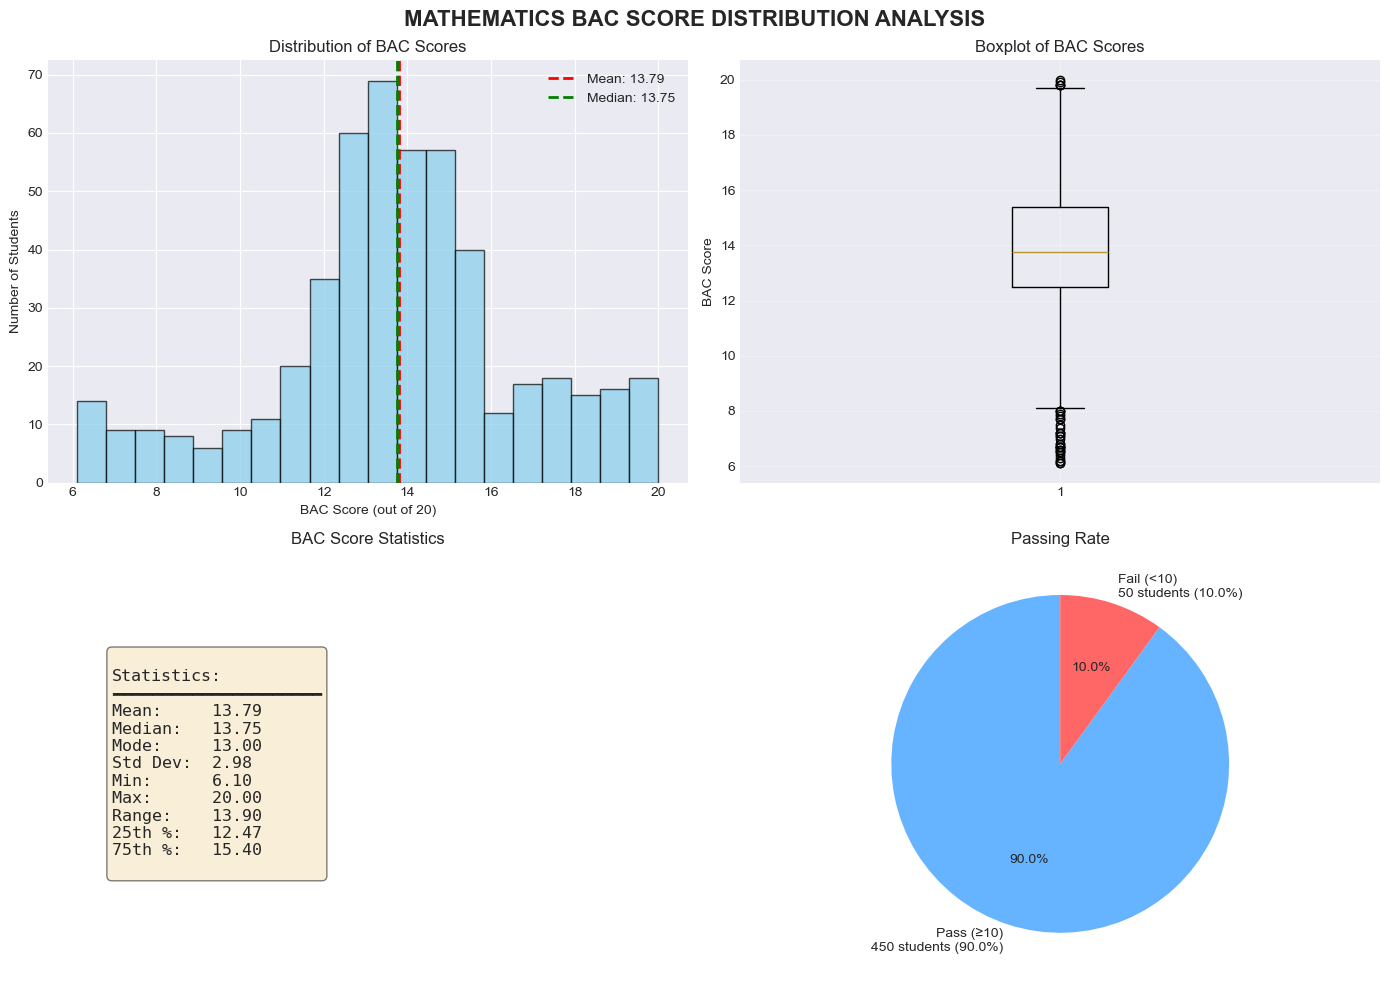


📊 BAC SCORE DISTRIBUTION SUMMARY
   Mean BAC Score:     13.79/20
   Median BAC Score:   13.75/20
   Standard Deviation: 2.98
   Pass Rate (≥10):    90.0% (450/500 students)
   Fail Rate (<10):    10.0% (50/500 students)


In [47]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of BAC scores
axes[0,0].hist(df['bac_score'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["bac_score"].mean():.2f}')
axes[0,0].axvline(df['bac_score'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df["bac_score"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score'].mean():.2f}
Median:   {df['bac_score'].median():.2f}
Mode:     {df['bac_score'].mode().iloc[0]:.2f}
Std Dev:  {df['bac_score'].std():.2f}
Min:      {df['bac_score'].min():.2f}
Max:      {df['bac_score'].max():.2f}
Range:    {df['bac_score'].max() - df['bac_score'].min():.2f}
25th %:   {df['bac_score'].quantile(0.25):.2f}
75th %:   {df['bac_score'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('MATHEMATICS BAC SCORE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 BAC SCORE DISTRIBUTION SUMMARY")
print("="*60)
print(f"   Mean BAC Score:     {df['bac_score'].mean():.2f}/20")
print(f"   Median BAC Score:   {df['bac_score'].median():.2f}/20")
print(f"   Standard Deviation: {df['bac_score'].std():.2f}")
print(f"   Pass Rate (≥10):    {passing/len(df)*100:.1f}% ({passing}/{len(df)} students)")
print(f"   Fail Rate (<10):    {failing/len(df)*100:.1f}% ({failing}/{len(df)} students)")
print("="*60)


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score                : 1.000
   functions_analysis       : 0.743
   analysis_block           : 0.702
   psychological_composite  : 0.693
   avg_grade                : 0.677
   algebra_block            : 0.662
   grade_t3                 : 0.635
   grade_t2                 : 0.624
   grade_t1                 : 0.622
   probability_block        : 0.621
   algebra_skill            : 0.571
   practice_intensity       : 0.525
   sequences_skill          : 0.508
   integral_calculus        : 0.504
   multi_step_solving       : 0.479
   probability_skill        : 0.476
   confidence               : 0.461
   algebraic_manipulation   : 0.458
   proof_reasoning          : 0.435
   graph_interpretation     : 0.410
   timed_exams_per_week     : 0.401
   complex_block            : 0.379
   complex_numbers          : 0.379
   consistency              : 0.354
   exam_time_management     : 0.334
   focus_concentration      : 0.318
   past_exams

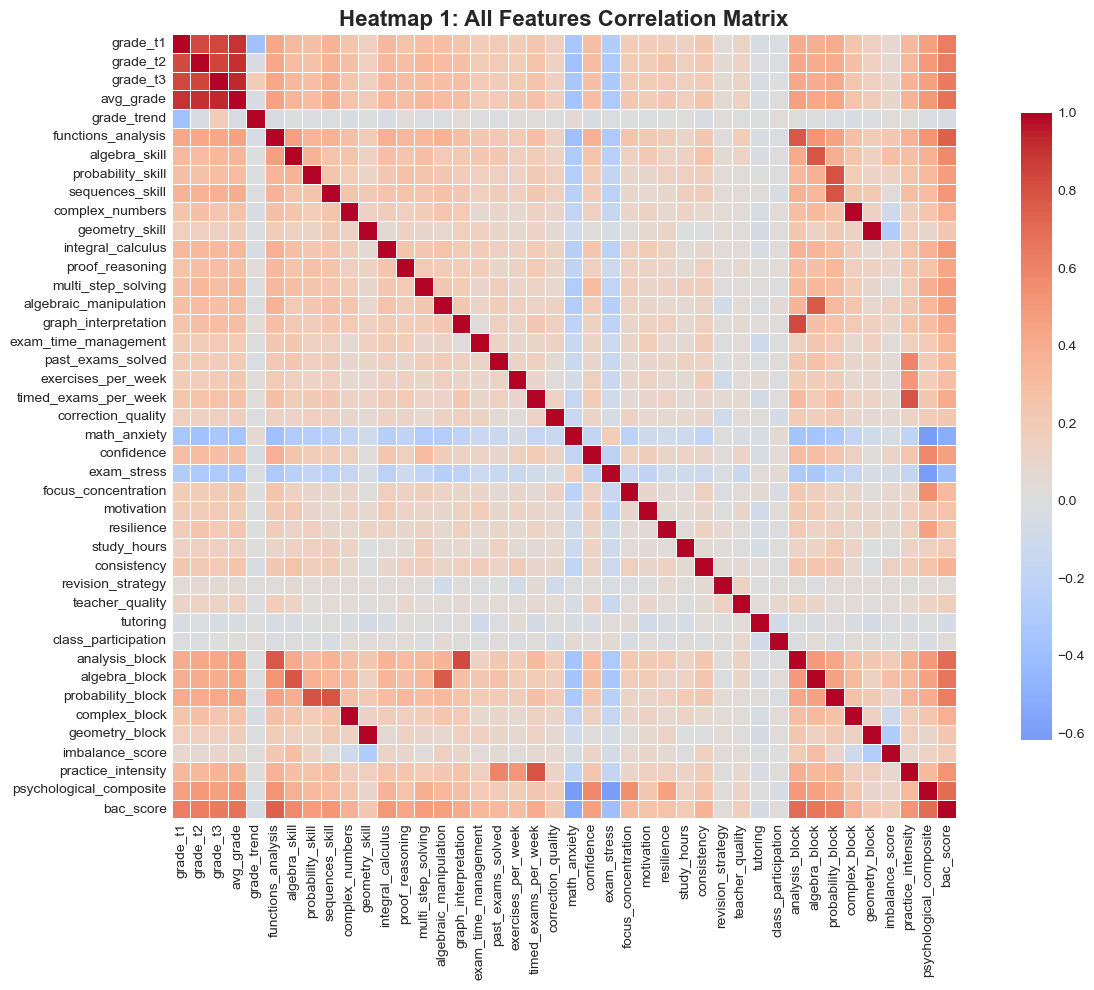


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


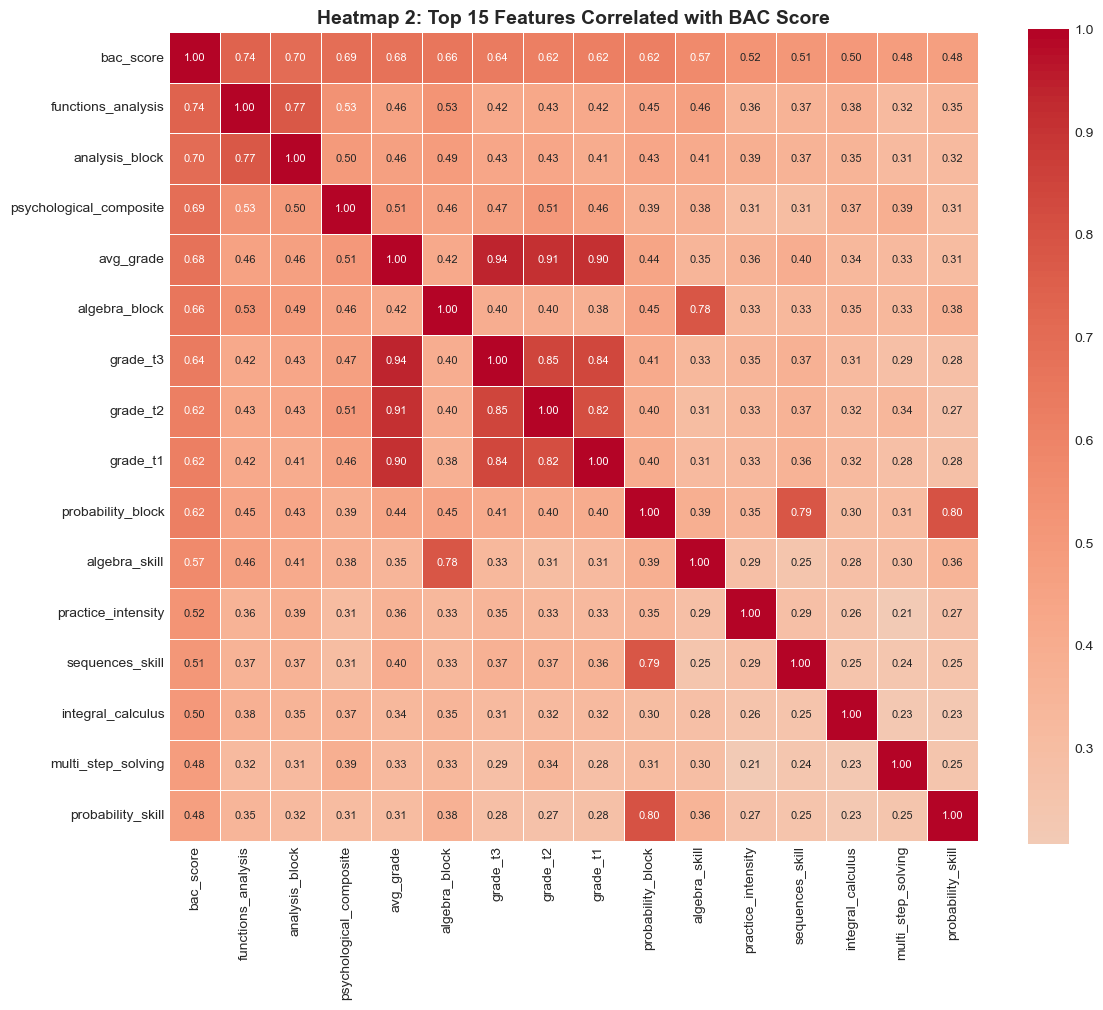


📊 HEATMAP 3: Skill Blocks Correlation


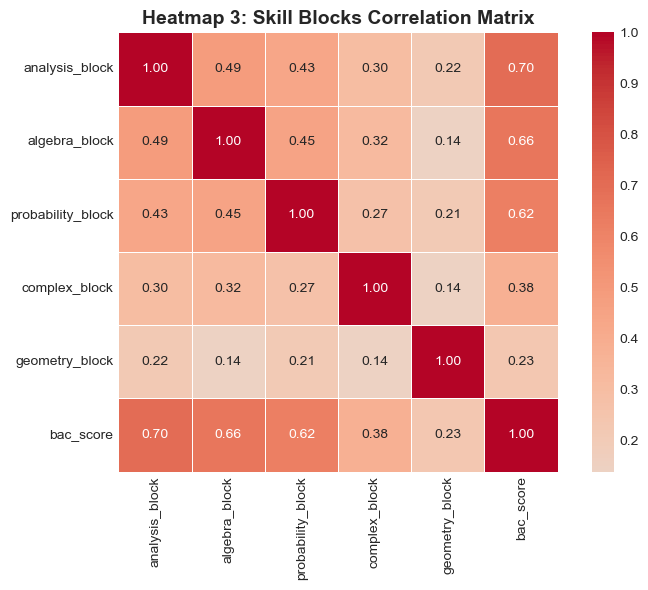


📋 Skill blocks correlation with BAC Score:
   • analysis_block: correlation = 0.702
   • algebra_block: correlation = 0.662
   • probability_block: correlation = 0.621
   • complex_block: correlation = 0.379
   • geometry_block: correlation = 0.233

📊 HEATMAP 4: Psychological Factors Correlation


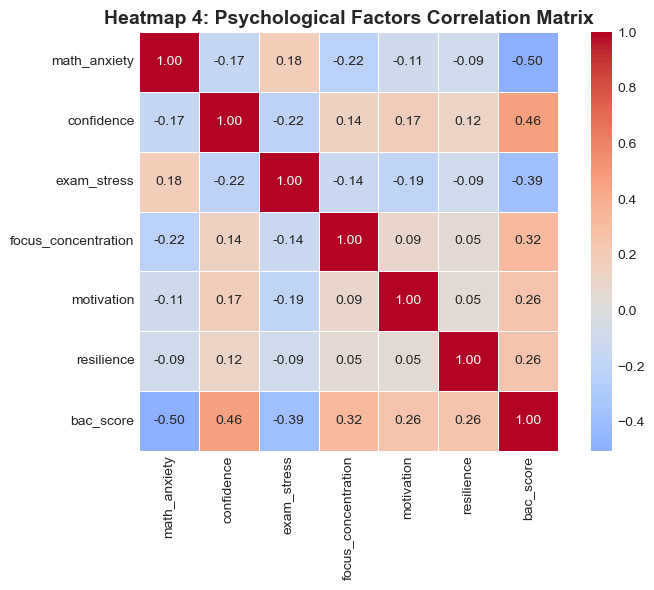


📋 Psychological factors correlation with BAC Score:
   • math_anxiety: correlation = -0.504
   • confidence: correlation = 0.461
   • exam_stress: correlation = -0.391
   • focus_concentration: correlation = 0.318
   • motivation: correlation = 0.258
   • resilience: correlation = 0.256

✅ Correlation Analysis Complete


In [48]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Get correlation with bac_score (target)
bac_corr = corr_matrix['bac_score'].sort_values(ascending=False)
print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 50)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:25s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: All Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top Features (highest correlation with BAC)
# ============================================
print("\n📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 50)

# Get top 15 features (excluding bac_score itself)
top_features = bac_corr.head(16).index.tolist()  # includes bac_score
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Skill Blocks Correlation
# ============================================
print("\n📊 HEATMAP 3: Skill Blocks Correlation")
print("=" * 50)

skill_blocks = ['analysis_block', 'algebra_block', 'probability_block', 'complex_block', 'geometry_block', 'bac_score']
available_blocks = [b for b in skill_blocks if b in df.columns]

if len(available_blocks) > 1:
    corr_blocks = df[available_blocks].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_blocks, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 3: Skill Blocks Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Skill blocks correlation with BAC Score:")
    for block in available_blocks:
        if block != 'bac_score':
            print(f"   • {block}: correlation = {corr_blocks[block]['bac_score']:.3f}")

# ============================================
# HEATMAP 4: Psychological Factors Correlation
# ============================================
print("\n📊 HEATMAP 4: Psychological Factors Correlation")
print("=" * 50)

psycho_cols = ['math_anxiety', 'confidence', 'exam_stress', 'focus_concentration', 'motivation', 'resilience', 'bac_score']
available_psycho = [p for p in psycho_cols if p in df.columns]

if len(available_psycho) > 1:
    corr_psycho = df[available_psycho].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_psycho, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 4: Psychological Factors Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Psychological factors correlation with BAC Score:")
    for factor in available_psycho:
        if factor != 'bac_score':
            print(f"   • {factor}: correlation = {corr_psycho[factor]['bac_score']:.3f}")

print("\n" + "=" * 50)
print("✅ Correlation Analysis Complete")
print("=" * 50)

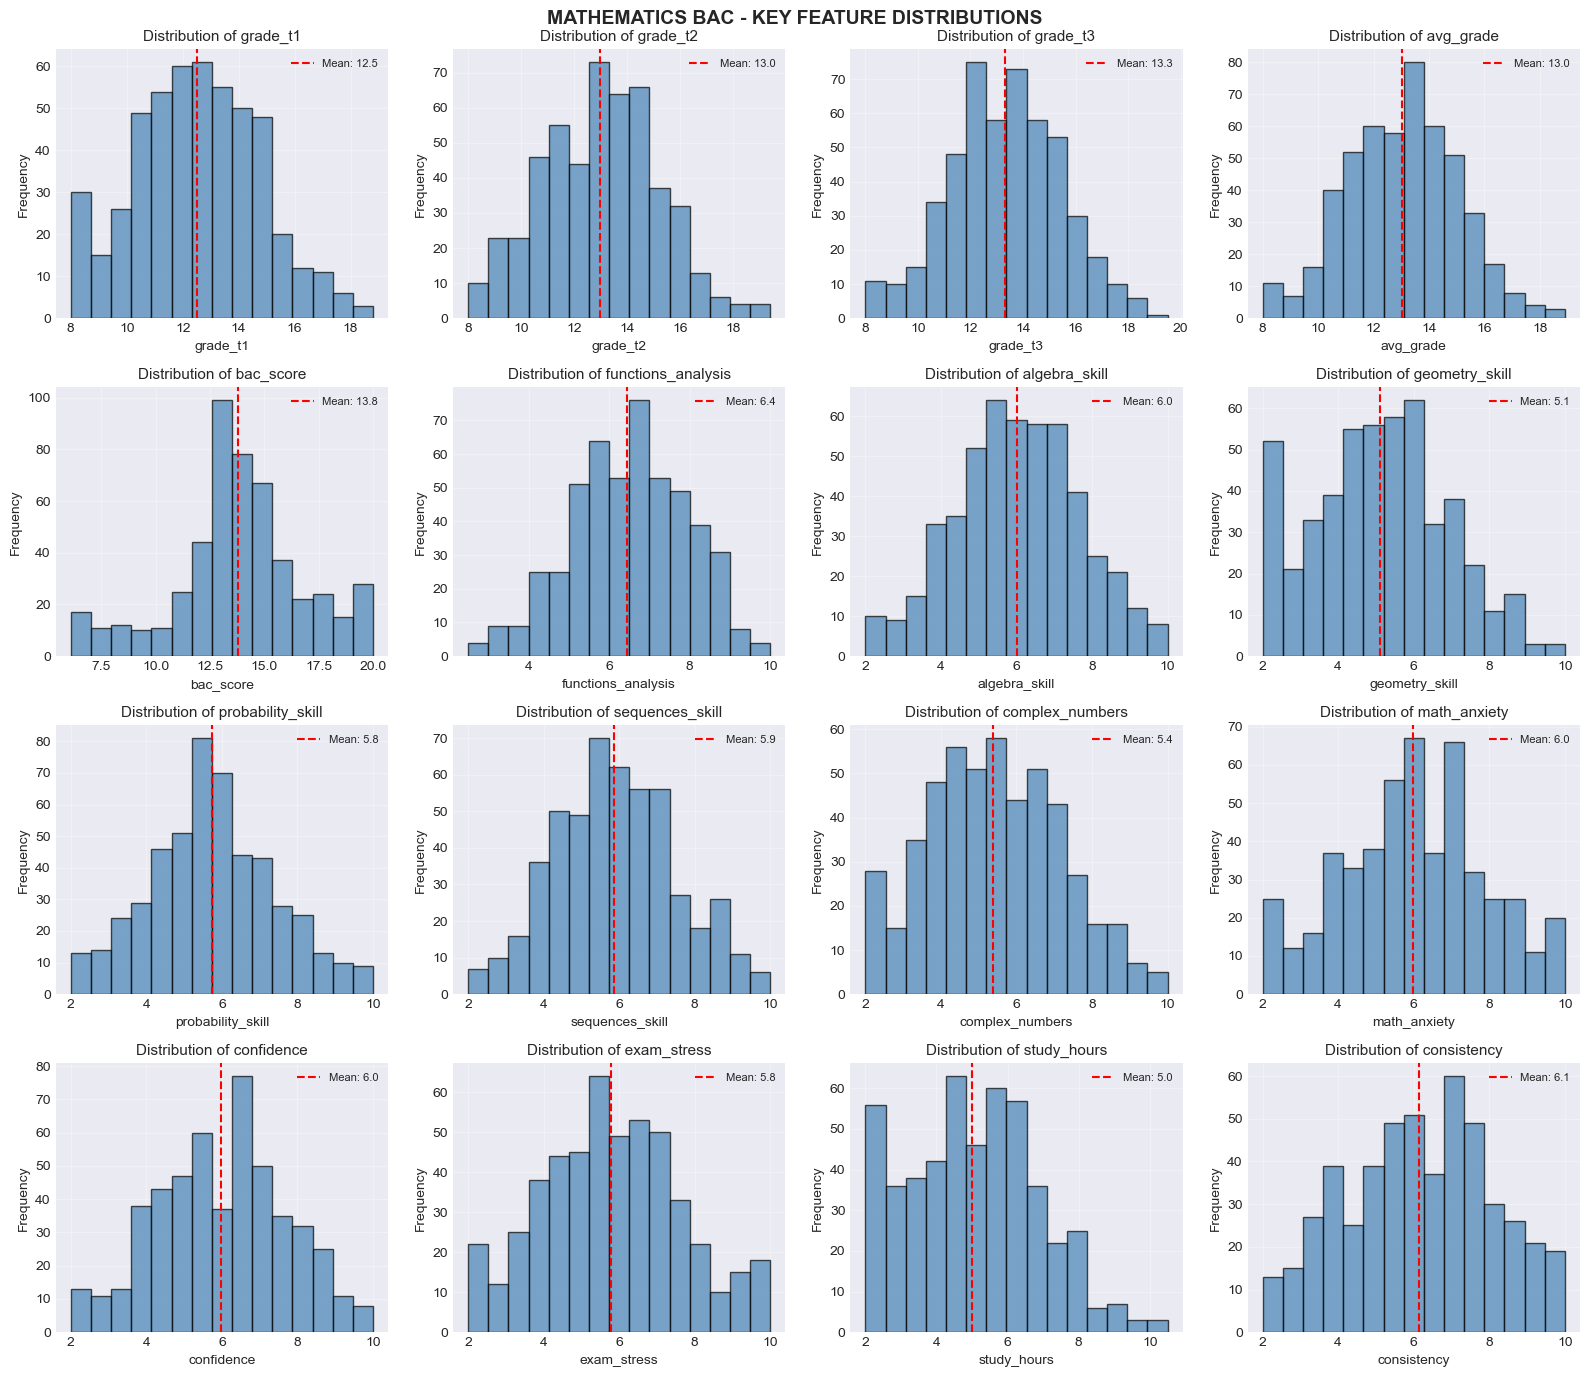


📊 KEY FEATURES SUMMARY STATISTICS
       grade_t1  grade_t2  grade_t3  avg_grade  bac_score  functions_analysis  \
count     500.0     500.0     500.0      500.0      500.0               500.0   
mean       12.5      13.0      13.3       13.0       13.8                 6.4   
std         2.2       2.2       2.1        2.0        3.0                 1.4   
min         8.0       8.0       8.0        8.0        6.1                 2.5   
25%        10.9      11.5      12.0       11.6       12.5                 5.5   
50%        12.5      13.1      13.3       13.1       13.8                 6.5   
75%        14.0      14.5      14.7       14.4       15.4                 7.5   
max        18.8      19.4      19.5       18.9       20.0                10.0   

       algebra_skill  geometry_skill  probability_skill  sequences_skill  \
count          500.0           500.0              500.0            500.0   
mean             6.0             5.1                5.8              5.9   
std    

In [50]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS 
# ============================================

import matplotlib.pyplot as plt

# Select key features to visualize (Mathematics specific)
key_features = [
    'grade_t1', 'grade_t2', 'grade_t3', 'avg_grade', 'bac_score',
    'functions_analysis', 'algebra_skill', 'geometry_skill', 
    'probability_skill', 'sequences_skill', 'complex_numbers',
    'math_anxiety', 'confidence', 'exam_stress',
    'study_hours', 'consistency'
]

# Filter only features that exist in dataframe
available_features = [f for f in key_features if f in df.columns]

# Calculate grid size (4x4 = 16, but we have 16 features exactly)
n_features = len(available_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('MATHEMATICS BAC - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics for key features
print("\n" + "=" * 60)
print("📊 KEY FEATURES SUMMARY STATISTICS")
print("=" * 60)

summary_stats = df[available_features].describe().round(1)
print(summary_stats)

# Additional math-specific stats
print("\n" + "=" * 60)
print("📊 MATHEMATICS SKILLS BREAKDOWN")
print("=" * 60)
skill_cols = ['functions_analysis', 'algebra_skill', 'probability_skill', 
              'sequences_skill', 'complex_numbers', 'geometry_skill']
available_skills = [s for s in skill_cols if s in df.columns]
if available_skills:
    print(df[available_skills].mean().round(1))
    print("\n📈 Skill importance order (by correlation with BAC):")
    for skill in available_skills:
        corr = df['bac_score'].corr(df[skill])
        print(f"   {skill}: {corr:.3f}")

In [3]:
# ============================================
# CELL 9: FEATURE ENGINEERING 
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy of the dataframe for feature engineering
df_fe = df.copy()

# ============================================
# 1. Analysis Composite Score (functions + graph interpretation)
# ============================================
df_fe['analysis_composite'] = (df_fe['functions_analysis'] + df_fe['graph_interpretation']) / 2
df_fe['analysis_composite'] = np.round(df_fe['analysis_composite'], 1)

# ============================================
# 2. Algebra Composite Score
# ============================================
df_fe['algebra_composite'] = (df_fe['algebra_skill'] + df_fe['algebraic_manipulation']) / 2
df_fe['algebra_composite'] = np.round(df_fe['algebra_composite'], 1)

# ============================================
# 3. Probability & Sequences Composite
# ============================================
df_fe['prob_seq_composite'] = (df_fe['probability_skill'] + df_fe['sequences_skill']) / 2
df_fe['prob_seq_composite'] = np.round(df_fe['prob_seq_composite'], 1)

# ============================================
# 4. Imbalance Score (variance between all skill blocks)
# ============================================
skill_blocks = ['analysis_block', 'algebra_block', 'probability_block', 'complex_block', 'geometry_block']
available_blocks = [b for b in skill_blocks if b in df_fe.columns]
df_fe['imbalance_score_v2'] = df_fe[available_blocks].var(axis=1)
df_fe['imbalance_score_v2'] = np.round(df_fe['imbalance_score_v2'], 2)

# ============================================
# 5. Practice Intensity (exams + exercises + timed exams)
# ============================================
df_fe['practice_intensity_v2'] = (
    df_fe['past_exams_solved'] / 30 * 10 + 
    df_fe['exercises_per_week'] / 20 * 10 + 
    df_fe['timed_exams_per_week'] / 5 * 10
) / 3
df_fe['practice_intensity_v2'] = np.round(df_fe['practice_intensity_v2'], 1)

# ============================================
# 6. Psychological Health Score (inverse of anxiety/stress, high = better)
# ============================================
df_fe['psychological_health'] = (
    df_fe['confidence'] + 
    df_fe['focus_concentration'] + 
    df_fe['resilience'] + 
    (10 - df_fe['math_anxiety']) + 
    (10 - df_fe['exam_stress'])
) / 5
df_fe['psychological_health'] = np.round(df_fe['psychological_health'], 1)

# ============================================
# 7. Study Quality Score
# ============================================
df_fe['study_quality'] = (
    df_fe['consistency'] * 0.4 +
    df_fe['study_hours'] / 15 * 10 * 0.3 +
    df_fe['correction_quality'] * 0.3
)
df_fe['study_quality'] = np.round(df_fe['study_quality'], 1)

# ============================================
# Display new features
# ============================================
print("\n✅ New features created:")
print("   • analysis_composite (functions_analysis + graph_interpretation)")
print("   • algebra_composite (algebra_skill + algebraic_manipulation)")
print("   • prob_seq_composite (probability_skill + sequences_skill)")
print("   • imbalance_score_v2 (variance across skill blocks)")
print("   • practice_intensity_v2 (exams + exercises + timed exams)")
print("   • psychological_health (confidence + focus + resilience - anxiety - stress)")
print("   • study_quality (consistency + study_hours + correction_quality)")

print("\n📊 First 5 rows (selected columns):")
selected_cols = ['bac_score', 'analysis_composite', 'algebra_composite', 'prob_seq_composite', 
                 'imbalance_score_v2', 'practice_intensity_v2', 'psychological_health', 'study_quality']
available_selected = [c for c in selected_cols if c in df_fe.columns]
print(df_fe[available_selected].head().to_string())

print("\n📊 New features statistics:")
print(df_fe[available_selected].describe().to_string())

# Store the enhanced dataframe
df = df_fe.copy()

print("\n✅ Feature engineering complete. Total columns:", df.shape[1])

FEATURE ENGINEERING

✅ New features created:
   • analysis_composite (functions_analysis + graph_interpretation)
   • algebra_composite (algebra_skill + algebraic_manipulation)
   • prob_seq_composite (probability_skill + sequences_skill)
   • imbalance_score_v2 (variance across skill blocks)
   • practice_intensity_v2 (exams + exercises + timed exams)
   • psychological_health (confidence + focus + resilience - anxiety - stress)
   • study_quality (consistency + study_hours + correction_quality)

📊 First 5 rows (selected columns):
   bac_score  analysis_composite  algebra_composite  prob_seq_composite  imbalance_score_v2  practice_intensity_v2  psychological_health  study_quality
0       14.4                 6.9                8.3                 5.8                3.10                    3.6                   4.9            5.8
1       19.3                 7.7                7.8                 7.2                1.10                    7.1                   7.0            7.6
2     

In [4]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# ============================================
# Define features (X) and target (y) for BAC prediction
# ============================================

# Keep avg_grade as a feature (it's the strongest predictor)
exclude_cols = ['bac_score']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['bac_score']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

TRAIN/TEST SPLIT

📊 Features (X): 49 columns
📊 Target (y): bac_score

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  functions_analysis  algebra_skill  probability_skill  sequences_skill  complex_numbers  geometry_skill  integral_calculus  proof_reasoning  multi_step_solving  algebraic_manipulation  graph_interpretation  exam_time_management  past_exams_solved  exercises_per_week  timed_exams_per_week  correction_quality  math_anxiety  confidence  exam_stress  focus_concentration  motivation  resilience  study_hours  consistency  revision_strategy  teacher_quality  tutoring  class_participation     stream  analysis_block  algebra_block  probability_block  complex_block  geometry_block  imbalance_score  practice_intensity  psychological_composite  analysis_composite  algebra_composite  prob_seq_composite  imbalance_score_v2  practice_intensity_v2  p

In [5]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT (with encoding)
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# ============================================
# Encode categorical variables
# ============================================

# Make a copy to avoid modifying original
df_encoded = df.copy()

# Encode 'stream' column if it exists
if 'stream' in df_encoded.columns:
    le = LabelEncoder()
    df_encoded['stream_encoded'] = le.fit_transform(df_encoded['stream'])
    df_encoded = df_encoded.drop('stream', axis=1)
    print("✅ Encoded 'stream' column to numeric:")
    for i, category in enumerate(le.classes_):
        print(f"   {category} → {i}")
else:
    print("✅ No categorical columns to encode")

# ============================================
# Define features (X) and target (y)
# ============================================

exclude_cols = ['bac_score']
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['bac_score']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df_encoded)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df_encoded)*100:.0f}%)")

# Update df for later cells
df = df_encoded.copy()

TRAIN/TEST SPLIT
✅ Encoded 'stream' column to numeric:
   Gestion → 0
   Lettres → 1
   Maths → 2
   Sciences → 3
   Technique → 4

📊 Features (X): 49 columns
📊 Target (y): bac_score

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)


In [6]:
# ============================================
# CELL 11: MODEL TRAINING
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING")
print("=" * 40)

# ============================================
# Train Random Forest Regressor
# ============================================

print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# ============================================
# Make predictions
# ============================================
y_pred = model.predict(X_test)

# ============================================
# Evaluate model
# ============================================
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
for i, row in feature_importance_df.head(15).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f}")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 40)
print("SAMPLE PREDICTIONS (First 10 test students)")
print("=" * 40)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred[:10], 1),
    'Error': np.round(y_test.values[:10] - y_pred[:10], 1)
})
print(sample_df.to_string())

print("\n✅ Model ready for Cell 12")

MODEL TRAINING

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  1.09 points
   RMSE: 1.35 points
   R²:   0.782

FEATURE IMPORTANCE

Top 15 most important features:
   functions_analysis                 : 0.3451
   avg_grade                          : 0.0967
   psychological_health               : 0.0567
   psychological_composite            : 0.0520
   algebra_block                      : 0.0471
   analysis_block                     : 0.0468
   algebra_composite                  : 0.0443
   analysis_composite                 : 0.0337
   grade_t1                           : 0.0267
   grade_t3                           : 0.0214
   prob_seq_composite                 : 0.0186
   probability_block                  : 0.0167
   algebra_skill                      : 0.0157
   confidence                         : 0.0125
   grade_t2                           : 0.0120

SAMPLE PREDICTIONS (First 10 test students)
   Actual  Predict

MODEL EVALUATION (DETAILED)

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     1.095 points
   Mean Squared Error (MSE):      1.812
   Root Mean Squared Error (RMSE): 1.346 points
   R² Score:                      0.782

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.970 (97.0%)

   Confusion Matrix:
   True Negatives (correct fail):  5
   False Positives:                1
   False Negatives:                2
   True Positives (correct pass):  92


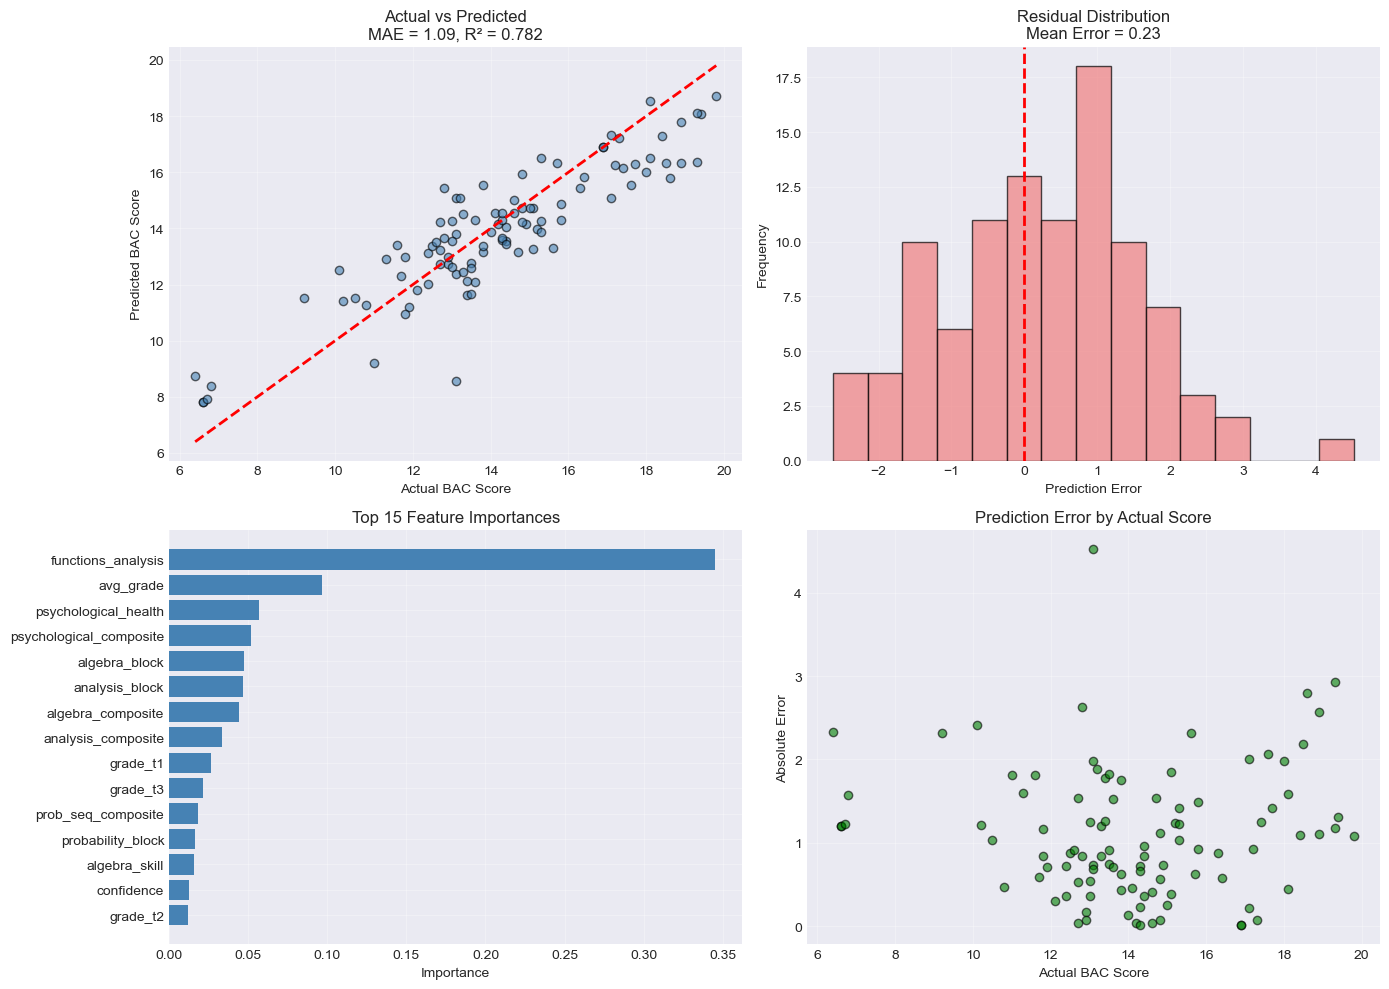


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      1.095 points
   Median Error:    0.942 points
   Max Error:       4.523 points
   Error < 1 point: 51.0% of predictions
   Error < 2 points: 88.0% of predictions

✅ Evaluation Complete


In [7]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED)
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("=" * 50)
print("MODEL EVALUATION (DETAILED)")
print("=" * 50)

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification
# ============================================
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

# ============================================
# 3. Visualizations
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual BAC Score')
axes[0,0].set_ylabel('Predicted BAC Score')
axes[0,0].set_title(f'Actual vs Predicted\nMAE = {mae:.2f}, R² = {r2:.3f}')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 15)
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

axes[1,0].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance')
axes[1,0].set_title('Top 15 Feature Importances')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Error by Actual Score
axes[1,1].scatter(y_test, np.abs(residuals), alpha=0.6, color='green', edgecolors='black')
axes[1,1].set_xlabel('Actual BAC Score')
axes[1,1].set_ylabel('Absolute Error')
axes[1,1].set_title('Prediction Error by Actual Score')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 4. Error Summary
# ============================================
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - MATHEMATICS BAC

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 49)


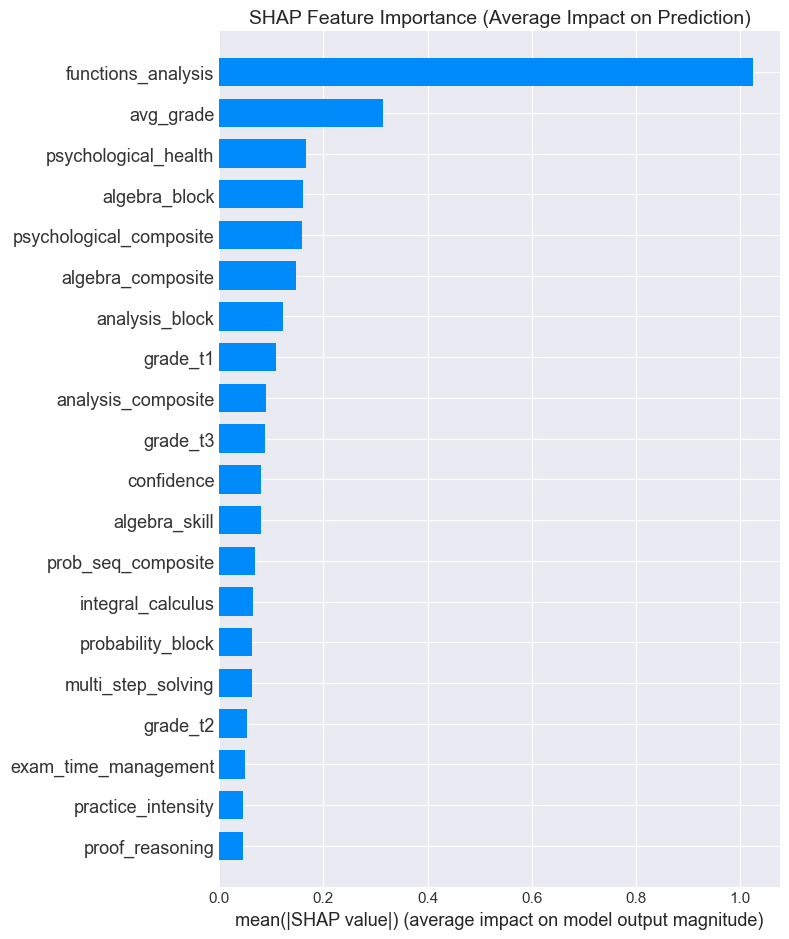

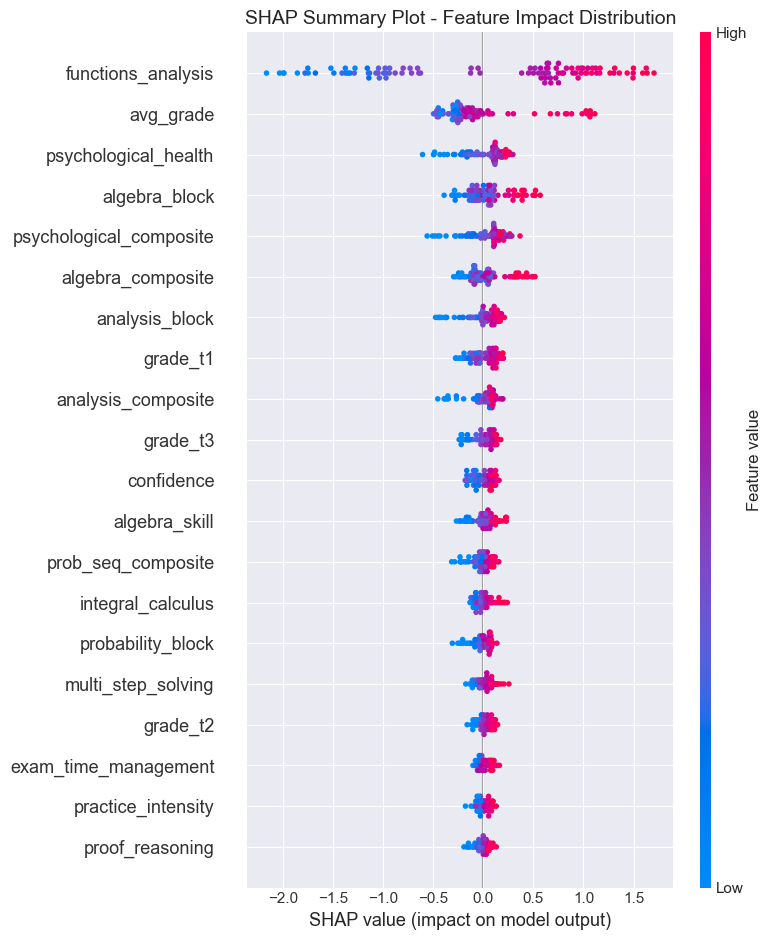


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual BAC score: 12.7
   Predicted BAC score: 13.2


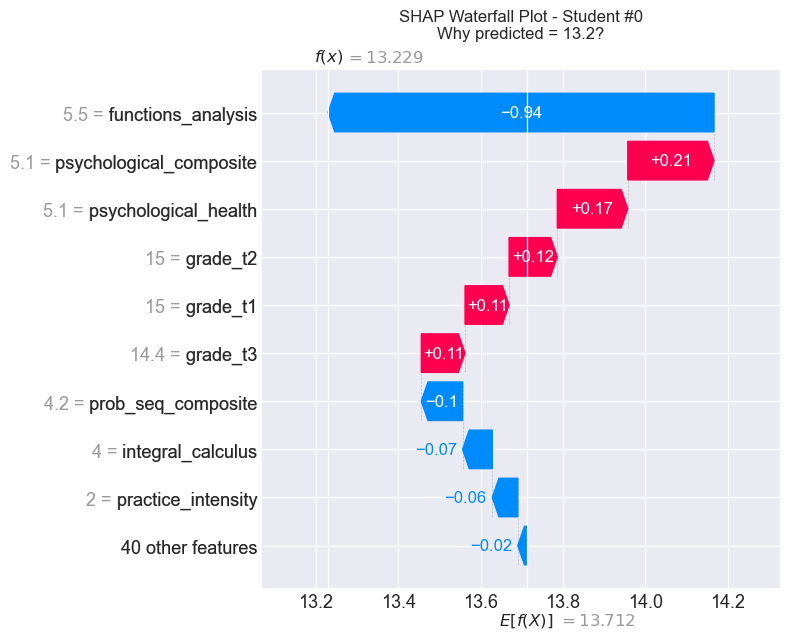


SIMPLE EXPLANATION (Student-Friendly)

✅ This student's predicted score: 13.2

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • functions_analysis: -0.94 points
   • prob_seq_composite: -0.10 points
   • integral_calculus: -0.07 points
   • practice_intensity: -0.06 points
   • probability_block: -0.05 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • psychological_composite: +0.21 points
   • psychological_health: +0.17 points
   • grade_t2: +0.12 points
   • grade_t1: +0.11 points
   • grade_t3: +0.11 points

✅ SHAP Explainability Complete


In [8]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - MATHEMATICS BAC")
print("=" * 50)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Impact on Prediction)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

# Pick the first student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual BAC score: {student_actual:.1f}")
print(f"   Predicted BAC score: {student_pred:.1f}")

# Create waterfall plot for this student
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Print SHAP explanation in simple terms
# ============================================
print("\n" + "=" * 50)
print("SIMPLE EXPLANATION (Student-Friendly)")
print("=" * 50)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with feature contributions
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df['absolute'] = np.abs(shap_df['shap_value'])
shap_df = shap_df.sort_values('absolute', ascending=False)

# Separate positive and negative contributions
positive = shap_df[shap_df['shap_value'] > 0].head(5)
negative = shap_df[shap_df['shap_value'] < 0].head(5)

print(f"\n✅ This student's predicted score: {student_pred:.1f}")
print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [9]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (PER STUDENT)
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - MATHEMATICS BAC")
print("=" * 50)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 10 students
# ============================================
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 10 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(10):
    print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations for Mathematics
# ============================================
print("\n" + "=" * 50)
print("ACTIONABLE RECOMMENDATIONS - MATHEMATICS")
print("=" * 50)

# Map features to Math-specific recommendations
recommendation_map = {
    # Academic
    'avg_grade': '📊 رفع المعدل العام في الفصول الثلاثة',
    'grade_t1': '📊 تحسين الأداء في الفصل الأول',
    'grade_t2': '📊 تحسين الأداء في الفصل الثاني',
    'grade_t3': '📊 تحسين الأداء في الفصل الثالث',
    'grade_trend': '📈 الحفاظ على تحسن مستمر في المعدلات',
    
    # Core Skills
    'functions_analysis': '📈 تحليل الدوال: ركز على النهايات، المشتقات، ودراسة الدوال',
    'algebra_skill': '🔢 الجبر: تدرب على حل المعادلات والمتراجحات',
    'probability_skill': '🎲 الاحتمالات: حل تمارين على شجرة الاحتمالات والقوانين',
    'sequences_skill': '📊 المتتاليات: راجع المتتاليات الحسابية والهندسية',
    'integral_calculus': '∫ التكامل: تدرب على حساب المساحات والدوال الأصلية',
    'complex_numbers': '🔢 الأعداد المركبة: راجع الشكل الجبري والمثلثي',
    'proof_reasoning': '📝 البرهان: تدرب على البرهان بالتراجع والاستدلال',
    'geometry_skill': '📐 الهندسة: راجع المتجهات والجداء السلمي',
    
    # Problem Solving
    'multi_step_solving': '🔗 حل مسائل متعددة الخطوات: قسم المسألة إلى خطوات صغيرة',
    'algebraic_manipulation': '✏️ العمليات الجبرية: تدرب على التبسيط والنشر والتحليل',
    'graph_interpretation': '📈 قراءة البيان: تدرب على استخراج المعلومات من المنحنيات',
    'exam_time_management': '⏰ إدارة الوقت: حل امتحانات كاملة بوقت محدد',
    
    # Psychological
    'math_anxiety': '🧘 القلق من الرياضيات: ابدأ بتمارين سهلة وزد الصعوبة تدريجياً',
    'confidence': '💪 الثقة بالنفس: حل تمارين متنوعة وزد ثقتك بقدراتك',
    'exam_stress': '😌 توتر الامتحان: تدرب على التنفس العميق وتنظيم الوقت',
    'focus_concentration': '🎯 التركيز: خذ فترات راحة قصيرة أثناء الدراسة',
    'motivation': '🎯 الدافعية: حدد أهدافاً يومية صغيرة وحققها',
    'resilience': '💪 الصمود: تعلم من أخطائك ولا تستسلم',
    
    # Practice
    'past_exams_solved': '📝 الامتحانات السابقة: حل امتحان بكالوريا كل أسبوع',
    'exercises_per_week': '✍️ التمارين: حل 10-15 تمرين أسبوعياً',
    'timed_exams_per_week': '⏱️ امتحانات بوقت: حل امتحان كامل بوقته الحقيقي',
    'correction_quality': '🔍 تصحيح الأخطاء: حلل أخطائك وافهم سببها',
    
    # Study Habits
    'study_hours': '⏰ ساعات الدراسة: خصص 6-8 ساعات أسبوعياً للرياضيات',
    'consistency': '📅 الانتظام: ذاكر يومياً بدلاً من المذاكرة المكثفة',
    'revision_strategy': '📖 استراتيجية المراجعة: راجع بانتظام وحل تمارين متنوعة',
    'teacher_quality': '👨‍🏫 جودة الأستاذ: اطلب المساعدة عند الحاجة',
    'class_participation': '🗣️ المشاركة في القسم: شارك في الحلول والمناقشات',
    
    # Derived
    'analysis_block': '📈 كتلة التحليل: ركز على دراسة الدوال والنهايات',
    'algebra_block': '🔢 كتلة الجبر: تدرب على حل المعادلات',
    'probability_block': '🎲 كتلة الاحتمالات: راجع قوانين الاحتمالات',
    'imbalance_score': '⚖️ عدم التوازن: وازن بين مهاراتك في جميع الفروع',
    'practice_intensity': '⚡ كثافة التمارين: زد عدد التمارين التي تحلها',
    'psychological_health': '🧠 الصحة النفسية: مارس الرياضة وتنفس بعمق',
    'study_quality': '📚 جودة الدراسة: ركز على الفهم وليس الحفظ'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:15]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        print(f"   • {weakness}: (ركز على تحسين هذا المجال)")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis_mathematics.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_mathematics.csv'")

print("\n" + "=" * 50)
print("✅ Weakness Analysis Complete")
print("=" * 50)

WEAKNESS ANALYSIS - MATHEMATICS BAC

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=12.7, Predicted=13.2
   🔴 Weaknesses:
      • functions_analysis (-0.94)
      • prob_seq_composite (-0.10)
      • integral_calculus (-0.07)
   🟢 Strengths:
      • psychological_composite (+0.21)
      • psychological_health (+0.17)
      • grade_t2 (+0.12)

🔹 STUDENT 2: Actual=18.6, Predicted=15.8
   🔴 Weaknesses:
      • avg_grade (-0.11)
      • algebra_composite (-0.09)
      • algebra_block (-0.08)
   🟢 Strengths:
      • functions_analysis (+1.27)
      • grade_t1 (+0.19)
      • analysis_block (+0.13)

🔹 STUDENT 3: Actual=15.1, Predicted=13.2
   🔴 Weaknesses:
      • functions_analysis (-1.38)
      • analysis_block (-0.29)
      • analysis_composite (-0.20)
   🟢 Strengths:
      • psychological_composite (+0.37)
      • psychological_health (+0.29)
      • multi_step_solving (+0.11)

🔹 STUDENT 4: Actual=16.9, Predicted=16.9
   🔴 W

SIMULATION ENGINE - MATHEMATICS BAC
How improving study habits affects your BAC score
Based on correlations from our dataset

📊 Real correlations from your data:
   functions_analysis → BAC: 0.743
   algebra_skill → BAC:      0.571
   probability_skill → BAC:  0.476
   geometry_skill → BAC:     0.233
   past_exams_solved → BAC:  0.314
   timed_exams → BAC:        0.401
   confidence → BAC:         0.461
   math_anxiety → BAC:       -0.504

👤 Selected student (average profile):
   Current BAC score: 13.8
   Functions & Analysis: 5.4/10
   Algebra: 5.7/10
   Geometry: 4.6/10
   Past exams solved: 17/30
   Timed exams/week: 4/5
   Confidence: 5.5/10
   Math Anxiety: 6.4/10

📈 SIMULATION RESULTS:
------------------------------------------------------------

🟢 📈 تحسين التحليل (دوال) +2 نقطة:
   13.8 → 15.6
   📈 التحسن: +1.78 نقطة

🟢 🔢 تحسين الجبر +2 نقطة:
   13.8 → 15.2
   📈 التحسن: +1.37 نقطة

🔵 📐 تحسين الهندسة +2 نقطة:
   13.8 → 14.4
   📈 التحسن: +0.56 نقطة

⚪ 📝 حل 10 امتحانات سابقة إضافي

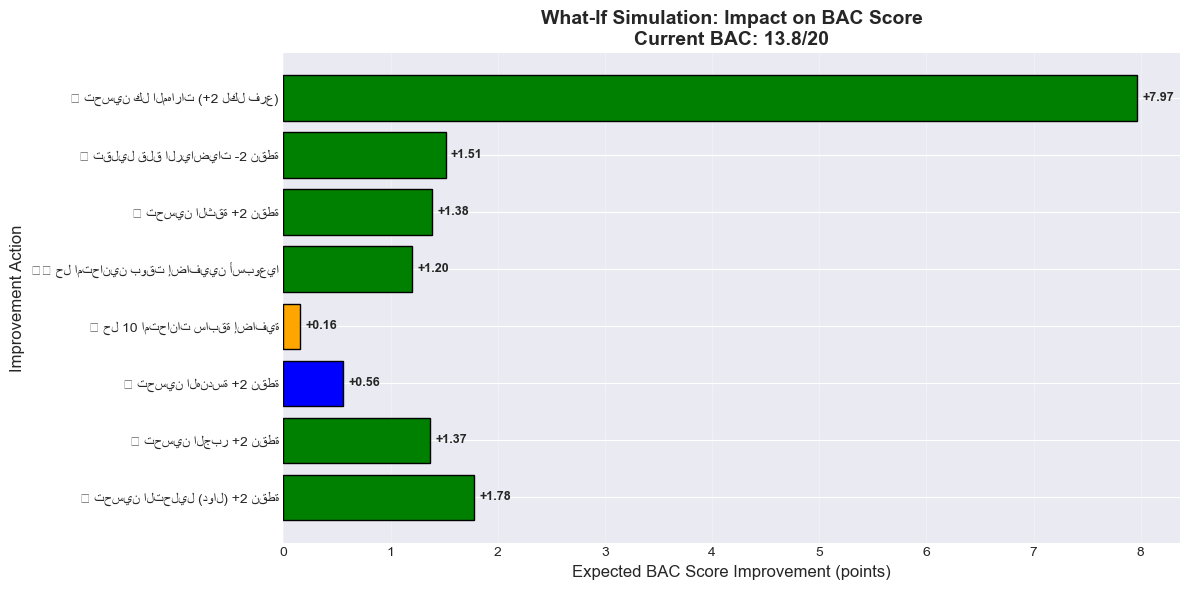


📊 جدول تأثير تحسين العادات الدراسية - الرياضيات


NameError: name 'scale_factors' is not defined

In [10]:
# ============================================
# CELL 15: SIMULATION ENGINE
# Shows how improving study habits affects BAC score
# Based on correlations from our dataset
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("SIMULATION ENGINE - MATHEMATICS BAC")
print("How improving study habits affects your BAC score")
print("Based on correlations from our dataset")
print("=" * 60)

# ============================================
# Step 1: Calculate average effects from correlations
# ============================================

# Get correlations with BAC score
bac_corr = df.corr()['bac_score']

# Extract key correlations (using actual column names)
functions_corr = bac_corr.get('functions_analysis', 0.50)
algebra_corr = bac_corr.get('algebra_skill', 0.35)
probability_corr = bac_corr.get('probability_skill', 0.30)
geometry_corr = bac_corr.get('geometry_skill', 0.15)
exam_corr = bac_corr.get('past_exams_solved', 0.25)
timed_exam_corr = bac_corr.get('timed_exams_per_week', 0.35)
confidence_corr = bac_corr.get('confidence', 0.30)
anxiety_corr = bac_corr.get('math_anxiety', -0.35)

print(f"\n📊 Real correlations from your data:")
print(f"   functions_analysis → BAC: {functions_corr:.3f}")
print(f"   algebra_skill → BAC:      {algebra_corr:.3f}")
print(f"   probability_skill → BAC:  {probability_corr:.3f}")
print(f"   geometry_skill → BAC:     {geometry_corr:.3f}")
print(f"   past_exams_solved → BAC:  {exam_corr:.3f}")
print(f"   timed_exams → BAC:        {timed_exam_corr:.3f}")
print(f"   confidence → BAC:         {confidence_corr:.3f}")
print(f"   math_anxiety → BAC:       {anxiety_corr:.3f}")

# ============================================
# Step 2: Find a representative student
# ============================================

# Find a student with average BAC (around 13)
avg_bac = df['bac_score'].mean()
target_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Selected student (average profile):")
print(f"   Current BAC score: {target_student['bac_score']:.1f}")
print(f"   Functions & Analysis: {target_student.get('functions_analysis', 5):.1f}/10")
print(f"   Algebra: {target_student.get('algebra_skill', 5):.1f}/10")
print(f"   Geometry: {target_student.get('geometry_skill', 5):.1f}/10")
print(f"   Past exams solved: {target_student.get('past_exams_solved', 5):.0f}/30")
print(f"   Timed exams/week: {target_student.get('timed_exams_per_week', 2):.0f}/5")
print(f"   Confidence: {target_student.get('confidence', 5):.1f}/10")
print(f"   Math Anxiety: {target_student.get('math_anxiety', 5):.1f}/10")

# ============================================
# Step 3: Simulation function
# ============================================

def simulate_improvement(student, improvements):
    """
    Simulate BAC improvement based on correlation coefficients
    """
    # Scale factors: how many BAC points per unit of improvement
    scale_factors = {
        'functions_analysis': functions_corr * 1.2,     # points per +1 skill
        'algebra_skill': algebra_corr * 1.2,
        'probability_skill': probability_corr * 1.2,
        'geometry_skill': geometry_corr * 1.2,
        'past_exams_solved': exam_corr * 0.5,           # points per +10 exams
        'timed_exams_per_week': timed_exam_corr * 1.5,  # points per +1 timed exam
        'confidence': confidence_corr * 1.5,
        'math_anxiety': -anxiety_corr * 1.5             # reducing anxiety helps
    }
    
    original_score = student['bac_score']
    gain = 0
    
    for feature, delta in improvements.items():
        if feature in scale_factors:
            if feature == 'past_exams_solved':
                gain += (delta / 10) * scale_factors[feature]
            elif feature == 'math_anxiety':
                # Reducing anxiety (negative delta) increases score
                gain += (-delta) * scale_factors[feature]
            else:
                gain += delta * scale_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Step 4: Test different scenarios
# ============================================

scenarios = [
    {"name": "📈 تحسين التحليل (دوال) +2 نقطة", "changes": {"functions_analysis": 2}},
    {"name": "🔢 تحسين الجبر +2 نقطة", "changes": {"algebra_skill": 2}},
    {"name": "📐 تحسين الهندسة +2 نقطة", "changes": {"geometry_skill": 2}},
    {"name": "📝 حل 10 امتحانات سابقة إضافية", "changes": {"past_exams_solved": 10}},
    {"name": "⏱️ حل امتحانين بوقت إضافيين أسبوعياً", "changes": {"timed_exams_per_week": 2}},
    {"name": "💪 تحسين الثقة +2 نقطة", "changes": {"confidence": 2}},
    {"name": "🧘 تقليل قلق الرياضيات -2 نقطة", "changes": {"math_anxiety": -2}},
    {"name": "✨ تحسين كل المهارات (+2 لكل فرع)", "changes": {
        "functions_analysis": 2, "algebra_skill": 2, "geometry_skill": 2,
        "past_exams_solved": 10, "timed_exams_per_week": 2, 
        "confidence": 2, "math_anxiety": -2
    }}
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement(target_student, scenario["changes"])
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 1.0:
        symbol = "🟢"
    elif result['gain'] > 0.5:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 التحسن: +{result['gain']:.2f} نقطة")

# ============================================
# Step 5: Best action recommendation
# ============================================

print("\n" + "=" * 60)
print("🎯 أفضل طريقة للتحسين - MATHEMATICS")
print("=" * 60)

best_gain = max([r['gain'] for r in results[:-1]])  # Exclude combined
best_scenario = scenarios[[r['gain'] for r in results[:-1]].index(best_gain)]

print(f"\n✅ {best_scenario['name']}")
print(f"   → تحسن متوقع: +{best_gain:.2f} نقطة في البكالوريا")

# ============================================
# Step 6: Visualization
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

scenario_names = [s["name"][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on BAC Score\nCurrent BAC: {target_student["bac_score"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Step 7: Summary table
# ============================================

print("\n" + "=" * 60)
print("📊 جدول تأثير تحسين العادات الدراسية - الرياضيات")
print("=" * 60)

impact_table = pd.DataFrame({
    'العادة الدراسية': [
        'تحسين التحليل (دوال) +2', 
        'تحسين الجبر +2', 
        'تحسين الهندسة +2',
        'حل 10 امتحانات سابقة',
        'امتحانين بوقت إضافيين',
        'تحسين الثقة +2',
        'تقليل قلق الرياضيات -2'
    ],
    'التحسن المتوقع': [
        f'+{scale_factors["functions_analysis"]*2:.2f} نقطة',
        f'+{scale_factors["algebra_skill"]*2:.2f} نقطة',
        f'+{scale_factors["geometry_skill"]*2:.2f} نقطة',
        f'+{scale_factors["past_exams_solved"]:.2f} نقطة',
        f'+{scale_factors["timed_exams_per_week"]*2:.2f} نقطة',
        f'+{scale_factors["confidence"]*2:.2f} نقطة',
        f'+{scale_factors["math_anxiety"]*2:.2f} نقطة'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 نصيحة خاصة لمادة الرياضيات:")
print("   • التحليل (الدوال والنهايات) هو الأكثر تأثيراً على نقطتك")
print("   • حل امتحانات كاملة بوقتها الحقيقي يحسن إدارة الوقت")
print("   • الثقة وتقليل القلق مهمان جداً في الرياضيات")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [11]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - MATHEMATICS
# ============================================

import pandas as pd
import numpy as np

print("=" * 60)
print("📖 فهم نتائجك في الرياضيات")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# ============================================
# Create a sample student profile
# ============================================

# Pick a student with average scores
sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# ============================================
# Explain each skill (using available columns)
# ============================================

print("\n📚 مهاراتك الأساسية في الرياضيات:")
print("-" * 60)

# Core Math Skills
skills_to_explain = [
    ('functions_analysis', '📈 التحليل (الدوال، النهايات، المشتقات)', 
     'هذا هو أهم جزء في البكالوريا! ركز على دراسة الدوال والنهايات'),
    ('algebra_skill', '🔢 الجبر (المعادلات، المتراجحات، الأعداد المركبة)',
     'تدرب على حل المعادلات والجبر'),
    ('probability_skill', '🎲 الاحتمالات (شجرة الاحتمالات، القوانين)',
     'حل تمارين على الاحتمالات والتباديل والتوافيق'),
    ('sequences_skill', '📊 المتتاليات (حسابية، هندسية، بالتراجع)',
     'راجع قوانين المتتاليات الحسابية والهندسية'),
    ('integral_calculus', '∫ التكامل (المساحات، الدوال الأصلية)',
     'تدرب على حساب المساحات والتكامل'),
    ('complex_numbers', '🔢 الأعداد المركبة (شكل جبري، مثلثي)',
     'راجع الأعداد المركبة وعملياتها'),
    ('proof_reasoning', '📝 البرهان (الاستدلال، البرهان بالتراجع)',
     'تدرب على كتابة براهين منطقية'),
    ('geometry_skill', '📐 الهندسة (المتجهات، الجداء السلمي)',
     'راجع الهندسة في المستوى والفضاء')
]

for skill, name, advice in skills_to_explain:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
            level_advice = f"مستواك {value:.1f}/10 - ممتاز! حافظ عليه"
        elif value >= 5:
            level = "🟡 متوسط"
            level_advice = f"مستواك {value:.1f}/10 - يمكن تحسينه"
        else:
            level = "🔴 يحتاج إلى تحسين"
            level_advice = f"مستواك {value:.1f}/10 - ركز على هذه المهارة"
        
        print(f"\n{name}")
        print(f"   → {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain psychological factors
# ============================================

print("\n" + "=" * 60)
print("🧠 العوامل النفسية وتأثيرها على أدائك في الرياضيات")
print("=" * 60)

psycho_factors = [
    ('math_anxiety', '😰 قلق الرياضيات', 
     'القلق يخفض نقطتك. ابدأ بتمارين سهلة وزد الصعوبة تدريجياً', True),
    ('confidence', '💪 الثقة بالنفس',
     'الثقة ترفع نقطتك. حل تمارين متنوعة وزد ثقتك بقدراتك', False),
    ('exam_stress', '😓 توتر الامتحان',
     'التوتر يؤثر سلباً. تدرب على التنفس العميق وتنظيم الوقت', True),
    ('focus_concentration', '🎯 التركيز',
     'التركيز يساعدك على حل المسائل بشكل أسرع وأدق', False),
    ('motivation', '🎯 الدافعية',
     'حدد أهدافاً يومية صغيرة وحققها لزيادة دافعيتك', False),
    ('resilience', '💪 الصمود',
     'تعلم من أخطائك ولا تستسلم عند مواجهة مسائل صعبة', False)
]

for factor, name, advice, is_negative in psycho_factors:
    if factor in df.columns:
        value = sample_student[factor]
        if is_negative:
            # For negative factors (anxiety, stress): lower is better
            if value <= 3:
                level = "🟢 ممتاز (منخفض)"
            elif value <= 6:
                level = "🟡 متوسط"
            else:
                level = "🔴 مرتفع (يؤثر سلباً)"
        else:
            # For positive factors: higher is better
            if value >= 7:
                level = "🟢 ممتاز"
            elif value >= 5:
                level = "🟡 متوسط"
            else:
                level = "🔴 منخفض (يحتاج تحسين)"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain study habits
# ============================================

print("\n" + "=" * 60)
print("📖 عادات الدراسة وتأثيرها على نقطتك في الرياضيات")
print("=" * 60)

study_habits = [
    ('past_exams_solved', '📚 عدد امتحانات البكالوريا التي حللتها', 30),
    ('exercises_per_week', '✍️ عدد التمارين التي تحلها أسبوعياً', 20),
    ('timed_exams_per_week', '⏱️ عدد الامتحانات الكاملة التي تحلها بوقت محدد', 5),
    ('study_hours', '⏰ عدد ساعات الدراسة الأسبوعية للرياضيات', 15),
    ('consistency', '📅 مدى انتظامك في الدراسة (من 1 إلى 10)', 10),
    ('correction_quality', '🔍 جودة تصحيحك لأخطائك وفهمها', 10)
]

for habit, name, max_val in study_habits:
    if habit in df.columns:
        value = sample_student[habit]
        percentage = (value / max_val) * 100
        
        if percentage >= 70:
            level = "🟢 ممتاز"
        elif percentage >= 50:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.0f}/{max_val}")
        print(f"   → مستواك: {level} ({percentage:.0f}%)")
        
        if habit == 'past_exams_solved' and value < 10:
            print(f"   💡 نصيحة: حاول حل {10 - value:.0f} امتحان إضافي")
        elif habit == 'exercises_per_week' and value < 10:
            print(f"   💡 نصيحة: ارفع عدد التمارين إلى 10-15 أسبوعياً")
        elif habit == 'timed_exams_per_week' and value < 2:
            print(f"   💡 نصيحة: حاول حل امتحان كامل بوقته الحقيقي كل أسبوع")
        elif habit == 'study_hours' and value < 6:
            print(f"   💡 نصيحة: زد ساعات الدراسة إلى 6-8 ساعات أسبوعياً")
        elif habit == 'consistency' and value < 6:
            print(f"   💡 نصيحة: حاول الدراسة يومياً بدلاً من المذاكرة المكثفة")
        elif habit == 'correction_quality' and value < 6:
            print(f"   💡 نصيحة: حلل أخطائك وافهم سببها قبل الانتقال إلى تمرين جديد")

# ============================================
# Derived features explanation
# ============================================

print("\n" + "=" * 60)
print("📊 مؤشرات مركبة (مشتقة من مهاراتك)")
print("=" * 60)

derived_features = []
for col in ['analysis_composite', 'algebra_composite', 'prob_seq_composite', 
            'practice_intensity_v2', 'psychological_health', 'study_quality', 'imbalance_score_v2']:
    if col in df.columns:
        derived_features.append(col)

if derived_features:
    for feature in derived_features:
        value = sample_student[feature]
        
        if feature == 'analysis_composite':
            print(f"\n📈 مستوى التحليل (دوال): {value:.1f}/10")
            print(f"   🤔 ماذا يعني؟ متوسط مهاراتك في النهايات والمشتقات ودراسة الدوال")
            if value >= 7:
                print("   ✅ مستواك ممتاز في التحليل - هذا يرفع نقطتك كثيراً!")
            elif value >= 5:
                print("   📈 مستواك جيد - استمر في التدرب على دراسة الدوال")
            else:
                print("   ⚠️ التحليل يحتاج إلى تحسين - ركز على النهايات والمشتقات")
        
        elif feature == 'algebra_composite':
            print(f"\n🔢 مستوى الجبر: {value:.1f}/10")
            print(f"   🤔 ماذا يعني؟ مهاراتك في حل المعادلات والجبر")
            if value >= 7:
                print("   ✅ ممتاز! الجبر لديك قوي")
            elif value >= 5:
                print("   📈 مستواك جيد - واصل التدرب")
            else:
                print("   ⚠️ راجع المعادلات والعمليات الجبرية")
        
        elif feature == 'practice_intensity_v2':
            print(f"\n⚡ كثافة التمارين: {value:.1f}/10")
            print(f"   🤔 ماذا يعني؟ مدى اجتهادك في حل الامتحانات والتمارين")
            if value >= 6:
                print("   ✅ أنت مجتهد - استمر بهذا المستوى!")
            elif value >= 4:
                print("   📈 اجتهادك جيد - حاول زيادة عدد الامتحانات التي تحلها")
            else:
                print("   ⚠️ تحتاج إلى حل المزيد من الامتحانات والتمارين")
        
        elif feature == 'psychological_health':
            print(f"\n🧠 الصحة النفسية: {value:.1f}/10")
            print(f"   🤔 ماذا يعني؟ مدى ثقتك وتركيزك وقلة قلقك في الرياضيات")
            if value >= 7:
                print("   ✅ حالتك النفسية ممتازة - هذا يساعدك كثيراً!")
            elif value >= 5:
                print("   📈 حالتك جيدة - حاول تقليل التوتر والقلق")
            else:
                print("   ⚠️ القلق والتوتر يؤثران سلباً - جرب تمارين الاسترخاء")
        
        elif feature == 'study_quality':
            print(f"\n📚 جودة الدراسة: {value:.1f}/10")
            print(f"   🤔 ماذا يعني؟ مدى انتظامك وتصحيحك للأخطاء وجودة مراجعتك")
            if value >= 7:
                print("   ✅ جودة دراستك ممتازة!")
            elif value >= 5:
                print("   📈 جيدة - يمكن تحسينها بتصحيح الأخطاء")
            else:
                print("   ⚠️ حاول تنظيم وقتك وتصحيح أخطائك بانتظام")
        
        elif feature == 'imbalance_score_v2':
            print(f"\n⚖️ توازن مهاراتك: {value:.2f}")
            print(f"   🤔 ماذا يعني؟ هل مهاراتك متوازنة بين فروع الرياضيات")
            if value < 0.5:
                print("   ✅ مهاراتك متوازنة - ممتاز! هذا نادر في الرياضيات")
            elif value < 1.0:
                print("   📈 هناك تفاوت بسيط - ركز على نقاط ضعفك")
            else:
                print("   ⚠️ هناك تفاوت كبير - أنت قوي في فروع وضعيف في أخرى")

# ============================================
# Final summary
# ============================================

print("\n" + "=" * 60)
print("🎯 ملخص وتوصيات مخصصة لك - الرياضيات")
print("=" * 60)

# Identify strongest and weakest skill
skill_values = {}
for skill, name, _ in skills_to_explain:
    if skill in df.columns:
        skill_values[name] = sample_student[skill]

if skill_values:
    weakest = min(skill_values, key=skill_values.get)
    strongest = max(skill_values, key=skill_values.get)
    
    print(f"\n🔴 أضعف مهارة لديك: {weakest}")
    print(f"🟢 أقوى مهارة لديك: {strongest}")

print(f"\n📋 توصيات للتحسين:")

recommendations = []

# Skill-based recommendations
if 'functions_analysis' in df.columns and sample_student['functions_analysis'] < 6:
    recommendations.append("• 📈 **التحليل (الدوال):** راجع النهايات والمشتقات وطريقة دراسة الدوال")
if 'algebra_skill' in df.columns and sample_student['algebra_skill'] < 6:
    recommendations.append("• 🔢 **الجبر:** تدرب على حل المعادلات من الدرجة الثانية والأعداد المركبة")
if 'geometry_skill' in df.columns and sample_student['geometry_skill'] < 5:
    recommendations.append("• 📐 **الهندسة:** راجع المتجهات والجداء السلمي في المستوى والفضاء")
if 'probability_skill' in df.columns and sample_student['probability_skill'] < 5:
    recommendations.append("• 🎲 **الاحتمالات:** حل تمارين على شجرة الاحتمالات والقوانين")

# Practice recommendations
if 'past_exams_solved' in df.columns and sample_student['past_exams_solved'] < 10:
    recommendations.append("• 📝 **حل امتحانات سابقة:** حل 10 امتحانات بكالوريا على الأقل")
if 'timed_exams_per_week' in df.columns and sample_student['timed_exams_per_week'] < 2:
    recommendations.append("• ⏱️ **امتحانات بوقت:** حل امتحان كامل بوقته الحقيقي (3-4 ساعات)")
if 'exercises_per_week' in df.columns and sample_student['exercises_per_week'] < 10:
    recommendations.append("• ✍️ **التمارين:** حل 10-15 تمرين أسبوعياً مع تنويع المواضيع")

# Psychological recommendations
if 'math_anxiety' in df.columns and sample_student['math_anxiety'] > 6:
    recommendations.append("• 🧘 **قلق الرياضيات:** ابدأ بتمارين سهلة وزد الصعوبة تدريجياً")
if 'confidence' in df.columns and sample_student['confidence'] < 5:
    recommendations.append("• 💪 **الثقة:** حل تمارين متنوعة وزد ثقتك بقدراتك")

for rec in recommendations[:6]:
    print(f"   {rec}")

if not recommendations:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: الرياضيات تحتاج إلى ممارسة يومية وفهم عميق")
print(f"   نقطتك الحالية: {sample_student['bac_score']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في الرياضيات
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 8.4/20
   معدل الفصول الثلاثة: 8.0/20

------------------------------------------------------------

📚 مهاراتك الأساسية في الرياضيات:
------------------------------------------------------------

📈 التحليل (الدوال، النهايات، المشتقات)
   → 🟢 قوي
   💡 نصيحة: هذا هو أهم جزء في البكالوريا! ركز على دراسة الدوال والنهايات

🔢 الجبر (المعادلات، المتراجحات، الأعداد المركبة)
   → 🔴 يحتاج إلى تحسين
   💡 نصيحة: تدرب على حل المعادلات والجبر

🎲 الاحتمالات (شجرة الاحتمالات، القوانين)
   → 🟡 متوسط
   💡 نصيحة: حل تمارين على الاحتمالات والتباديل والتوافيق

📊 المتتاليات (حسابية، هندسية، بالتراجع)
   → 🟡 متوسط
   💡 نصيحة: راجع قوانين المتتاليات الحسابية والهندسية

∫ التكامل (المساحات، الدوال الأصلية)
   → 🟡 متوسط
   💡 نصيحة: تدرب على حساب المساحات والتكامل

🔢 الأعداد المركبة (شكل جبري، مثلثي)
   → 🟡 متوسط
   💡 نصيحة: راجع الأعداد المركبة وعملياتها

📝 البرهان (الاستدلال، البرهان بالتراجع)
   → 🔴 يح

In [3]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - WITH LITTERAIRE
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("📚 منصة تحسين الأداء في الرياضيات - البكالوريا الجزائرية")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📐 امتحان البكالوريا - الرياضيات</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعب: رياضيات، تقني رياضي، علوم تجريبية، تسيير واقتصاد، آداب وفلسفة، لغات أجنبية</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">2سا 30د - 4سا 30د</div>
            <div style="font-size: 12px; color: #666;">(حسب الشعبة)</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">موضوعان</div>
            <div style="font-size: 14px;">اختيار موضوع واحد</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في الرياضيات</h2>
    </div>
"""

# Exam structure by stream - ADDED LITTERAIRE
stream_structure = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #e74c3c;">
        <h3 style="color: #2c3e50; margin-top: 0;">📐 شعبة الرياضيات + تقني رياضي (4سا 30د)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #e74c3c; color: white;">
                <th style="padding: 10px; text-align: center;">التمرين</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الأول</strong></td>
                <td style="padding: 10px;">الاحتمالات + المتتاليات</td>
                <td style="padding: 10px; text-align: center;">4-5 نقاط</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثاني</strong></td>
                <td style="padding: 10px;">المتتاليات + الأعداد المركبة</td>
                <td style="padding: 10px; text-align: center;">4-5 نقاط</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الثالث</strong></td>
                <td style="padding: 10px;">الحساب + الجبر + الأعداد المركبة</td>
                <td style="padding: 10px; text-align: center;">4-5 نقاط</td>
            </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الرابع</strong></td>
                <td style="padding: 10px;">التحليل + الدوال + التكامل</td>
                <td style="padding: 10px; text-align: center;">7-8 نقاط</td>
            </tr>
        </table>
    </div>
    
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">🧪 شعبة علوم تجريبية (3سا 30د)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">التمرين</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الأول</strong></td>
                <td style="padding: 10px;">الاحتمالات + المتتاليات</td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثاني</strong></td>
                <td style="padding: 10px;">المتتاليات + الأعداد المركبة</td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثالث</strong></td>
                <td style="padding: 10px;">التحليل + الدوال</td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
             </tr>
         </table>
    </div>
    
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #2ecc71;">
        <h3 style="color: #2c3e50; margin-top: 0;">📊 شعبة تسيير واقتصاد (3سا 30د)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #2ecc71; color: white;">
                <th style="padding: 10px; text-align: center;">التمرين</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الأول</strong></td>
                <td style="padding: 10px;">المتتاليات</td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثاني</strong></td>
                <td style="padding: 10px;">الاحتمالات</td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثالث</strong></td>
                <td style="padding: 10px;">التحليل + الدوال</td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
             </tr>
         </table>
    </div>
    
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #2c3e50; margin-top: 0;">📖 شعبة آداب وفلسفة + لغات أجنبية (2سا 30د)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #9b59b6; color: white;">
                <th style="padding: 10px; text-align: center;">التمرين</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>التمرين الأول</strong></td>
                <td style="padding: 10px;">المتتاليات العددية</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثاني</strong></td>
                <td style="padding: 10px;">الاحتمالات والإحصاء</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>التمرين الثالث</strong></td>
                <td style="padding: 10px;">التحليل والدوال (أساسيات)</td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
             </tr>
         </table>
        <p style="color: #666; font-size: 12px; margin-top: 10px;">📌 ملاحظة: مواد الرياضيات في الشعب الأدبية أخف بكثير وتغطي أساسيات فقط</p>
    </div>
"""

# Importance colors explanation
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 ما هي المهارات الأكثر أهمية في الرياضيات؟</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>التحليل (الدوال)</strong></div>
                <div style="font-size: 12px; color: #666;">الأكثر تأثيراً (35-40%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>الجبر والمتتاليات</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير كبير (25-30%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>الاحتمالات</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير متوسط (15-20%)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>الهندسة</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير أقل (10-15%)</div>
            </div>
        </div>
    </div>
"""

# Psychological note for Maths
psycho_note = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">🧠 ملاحظة مهمة حول الجانب النفسي في الرياضيات</h3>
        <p style="line-height: 1.6;">
            • <strong>قلق الرياضيات</strong> يؤثر سلباً على الأداء - 0.5 نقطة لكل درجة قلق<br>
            • <strong>الثقة بالنفس</strong> ترفع النقطة - 0.45 نقطة لكل درجة ثقة<br>
            • <strong>التوتر في الامتحان</strong> يخفض النقطة بمقدار 0.4 نقطة لكل درجة<br>
            • الرياضيات هي أكثر المواد تأثراً بالعوامل النفسية!
        </p>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - أدخل درجاتك ومستوياتك في المهارات المختلفة</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة في البكالوريا</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - سنحدد المهارات التي تحتاج إلى تحسين</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تغيير عاداتك الدراسية وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك في الرياضيات</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + stream_structure + importance_html + psycho_note + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة في الرياضيات ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا على تحسين أدائهم في الرياضيات</p>
        <p style="color: #888; font-size: 12px;">📐 الرياضيات تحتاج إلى ممارسة يومية وفهم عميق - نحن هنا لمساعدتك 📐</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

📚 منصة تحسين الأداء في الرياضيات - البكالوريا الجزائرية


التمرين,المحتوى,النقاط
التمرين الأول,الاحتمالات + المتتاليات,4-5 نقاط
التمرين الثاني,المتتاليات + الأعداد المركبة,4-5 نقاط
التمرين الثالث,الحساب + الجبر + الأعداد المركبة,4-5 نقاط
التمرين الرابع,التحليل + الدوال + التكامل,7-8 نقاط
التمرين,المحتوى,النقاط
التمرين الأول,الاحتمالات + المتتاليات,4 نقاط
التمرين الثاني,المتتاليات + الأعداد المركبة,4 نقاط
التمرين الثالث,التحليل + الدوال,8 نقاط
التمرين,المحتوى,النقاط
التمرين الأول,المتتاليات,4 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [4]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - MATHEMATICS
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - الرياضيات")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك في الرياضيات</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Stream Selection (Filiere)
# ============================================

stream_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 1. اختر شعبتك الدراسية</h3>
    <p style="color: #666; font-size: 14px;">ملاحظة: تختلف مدة الامتحان ومحتواه حسب الشعبة</p>
</div>
"""
display(HTML(stream_html))

stream_dropdown = widgets.Dropdown(
    options=[
        ('الرياضيات', 'Maths'),
        ('تقني رياضي', 'Technique'),
        ('علوم تجريبية', 'Sciences'),
        ('تسيير واقتصاد', 'Gestion'),
        ('آداب وفلسفة', 'Lettres'),
        ('لغات أجنبية', 'Langues')
    ],
    value='Sciences',
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(stream_dropdown)

# ============================================
# SECTION 2: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك في مادة الرياضيات من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 3: Core Mathematical Skills (0-10 scale)
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 3. مستوى مهاراتك في الرياضيات</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0 = ضعيف جداً، 10 = ممتاز)</p>
    <p style="color: #e74c3c; font-size: 12px;">⚠️ ملاحظة: مهارة التحليل (الدوال) هي الأكثر تأثيراً على نقطتك!</p>
</div>
"""
display(HTML(skills_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# Analysis & Functions (MOST IMPORTANT)
analysis_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='📈 التحليل (الدوال، النهايات، المشتقات):', 
                                       style={'description_width': '220px'}, layout=skill_style)

# Algebra
algebra_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                      description='🔢 الجبر (المعادلات، المتراجحات):', 
                                      style={'description_width': '220px'}, layout=skill_style)

# Probability
probability_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                          description='🎲 الاحتمالات (شجرة، قوانين):', 
                                          style={'description_width': '220px'}, layout=skill_style)

# Sequences
sequences_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='📊 المتتاليات (حسابية، هندسية):', 
                                        style={'description_width': '220px'}, layout=skill_style)

# Complex Numbers
complex_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                      description='🔢 الأعداد المركبة (شكل جبري، مثلثي):', 
                                      style={'description_width': '220px'}, layout=skill_style)

# Geometry
geometry_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='📐 الهندسة (متجهات، جداء سلمي):', 
                                       style={'description_width': '220px'}, layout=skill_style)

# Integral Calculus
integral_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                       description='∫ التكامل (مساحات، دوال أصلية):', 
                                       style={'description_width': '220px'}, layout=skill_style)

# Proof Reasoning
proof_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='📝 البرهان (استدلال، برهان بالتراجع):', 
                                    style={'description_width': '220px'}, layout=skill_style)

# Display skills in tabs
skill_tabs = widgets.Tab()
skill_tabs.children = [
    widgets.VBox([analysis_slider, algebra_slider, probability_slider, sequences_slider]),
    widgets.VBox([complex_slider, geometry_slider, integral_slider, proof_slider])
]
skill_tabs.set_title(0, '📐 المهارات الأساسية')
skill_tabs.set_title(1, '🔢 مهارات متقدمة')
display(skill_tabs)

# ============================================
# SECTION 4: Problem-Solving Skills
# ============================================

problem_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">⚙️ 4. مهارات حل المسائل</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(problem_html))

multi_step_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='🔗 حل مسائل متعددة الخطوات:', 
                                         style={'description_width': '220px'}, layout=skill_style)
graph_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='📈 قراءة وتحليل المنحنيات:', 
                                    style={'description_width': '220px'}, layout=skill_style)
time_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                   description='⏰ إدارة الوقت في الامتحان:', 
                                   style={'description_width': '220px'}, layout=skill_style)

display(multi_step_slider, graph_slider, time_slider)

# ============================================
# SECTION 5: Psychological Factors (HIGH IMPORTANCE FOR MATHS!)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 5. العوامل النفسية (مهمة جداً في الرياضيات!)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10 - هذه العوامل تؤثر بشكل كبير على أدائك في الرياضيات</p>
</div>
"""
display(HTML(psycho_html))

anxiety_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                      description='😰 قلق الرياضيات (1=لا قلق، 10=قلق شديد):', 
                                      style={'description_width': '250px'}, layout=skill_style)
confidence_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                         description='💪 الثقة بالنفس في الرياضيات:', 
                                         style={'description_width': '250px'}, layout=skill_style)
stress_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                     description='😓 توتر الامتحان:', 
                                     style={'description_width': '250px'}, layout=skill_style)
focus_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                    description='🎯 القدرة على التركيز:', 
                                    style={'description_width': '250px'}, layout=skill_style)

display(anxiety_slider, confidence_slider, stress_slider, focus_slider)

# ============================================
# SECTION 6: Study Habits & Practice
# ============================================

habits_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 6. عادات الدراسة والتمرين</h3>
    <p style="color: #666; font-size: 14px;">أدخل معلومات عن عاداتك الدراسية في الرياضيات</p>
</div>
"""
display(HTML(habits_html))

exams_slider = widgets.IntSlider(value=5, min=0, max=30, step=1, 
                                  description='📚 عدد امتحانات البكالوريا التي حللتها:', 
                                  style={'description_width': '250px'}, layout=skill_style)
exercises_slider = widgets.IntSlider(value=5, min=0, max=20, step=1, 
                                      description='✍️ عدد التمارين التي تحلها أسبوعياً:', 
                                      style={'description_width': '250px'}, layout=skill_style)
timed_slider = widgets.IntSlider(value=1, min=0, max=5, step=1, 
                                  description='⏱️ عدد الامتحانات الكاملة التي تحلها بوقت محدد أسبوعياً:', 
                                  style={'description_width': '250px'}, layout=skill_style)
hours_slider = widgets.FloatSlider(value=5, min=2, max=15, step=0.5, 
                                    description='⏰ عدد ساعات الدراسة الأسبوعية للرياضيات:', 
                                    style={'description_width': '250px'}, layout=skill_style)

display(exams_slider, exercises_slider, timed_slider, hours_slider)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

# Create stylish submit button
submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (رياضيات)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    # Clear previous output
    clear_output(wait=True)
    
    # Re-display the form (to keep it visible)
    display(HTML(form_header))
    display(stream_dropdown)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(skills_html))
    display(skill_tabs)
    display(HTML(problem_html))
    display(multi_step_slider, graph_slider, time_slider)
    display(HTML(psycho_html))
    display(anxiety_slider, confidence_slider, stress_slider, focus_slider)
    display(HTML(habits_html))
    display(exams_slider, exercises_slider, timed_slider, hours_slider)
    display(submit_button)
    
    # Collect values
    user_input = {
        'stream': stream_dropdown.value,
        'grade_t1': grade_slider1.value,
        'grade_t2': grade_slider2.value,
        'grade_t3': grade_slider3.value,
        'avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'functions_analysis': analysis_slider.value,
        'algebra_skill': algebra_slider.value,
        'probability_skill': probability_slider.value,
        'sequences_skill': sequences_slider.value,
        'complex_numbers': complex_slider.value,
        'geometry_skill': geometry_slider.value,
        'integral_calculus': integral_slider.value,
        'proof_reasoning': proof_slider.value,
        'multi_step_solving': multi_step_slider.value,
        'graph_interpretation': graph_slider.value,
        'exam_time_management': time_slider.value,
        'past_exams_solved': exams_slider.value,
        'exercises_per_week': exercises_slider.value,
        'timed_exams_per_week': timed_slider.value,
        'study_hours': hours_slider.value,
        'math_anxiety': anxiety_slider.value,
        'confidence': confidence_slider.value,
        'exam_stress': stress_slider.value,
        'focus_concentration': focus_slider.value
    }
    
    # Store in global variable for other cells
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   الشعبة: {stream_dropdown.value}")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   مستوى التحليل (الدوال): {analysis_slider.value}/10")
    print(f"   مستوى الجبر: {algebra_slider.value}/10")
    print(f"   قلق الرياضيات: {anxiety_slider.value}/10")
    print(f"   عدد الامتحانات المحلولة: {exams_slider.value}")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

# Attach function to button
submit_button.on_click(collect_inputs)

display(submit_button)

print("\n💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق")
print("💡 تذكر: التحليل (الدوال) هو الأكثر أهمية في الرياضيات!")

📝 إدخال بيانات الطالب - الرياضيات


Dropdown(index=2, layout=Layout(padding='10px', width='100%'), options=(('الرياضيات', 'Maths'), ('تقني رياضي',…

FloatSlider(value=6.0, description='🔗 حل مسائل متعددة الخطوات:', layout=Layout(padding='5px', width='100%'), m…

FloatSlider(value=6.0, description='📈 قراءة وتحليل المنحنيات:', layout=Layout(padding='5px', width='100%'), ma…

FloatSlider(value=6.0, description='⏰ إدارة الوقت في الامتحان:', layout=Layout(padding='5px', width='100%'), m…

...

IntSlider(value=1, description='⏱️ عدد الامتحانات الكاملة التي تحلها بوقت محدد أسبوعياً:', layout=Layout(paddi…

FloatSlider(value=5.0, description='⏰ عدد ساعات الدراسة الأسبوعية للرياضيات:', layout=Layout(padding='5px', wi…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (رياضيات)', icon='check', layout=Layou…


💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق
💡 تذكر: التحليل (الدوال) هو الأكثر أهمية في الرياضيات!


In [67]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - MATHEMATICS
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction using the trained model
    # ============================================
    
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input_data])
    
    # Add derived features (same as Cell 9)
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    input_df['analysis_composite'] = (input_df['functions_analysis'] + input_df['graph_interpretation']) / 2
    input_df['algebra_composite'] = (input_df['algebra_skill']) / 2
    input_df['prob_seq_composite'] = (input_df['probability_skill'] + input_df['sequences_skill']) / 2
    input_df['practice_intensity_v2'] = (
        input_df['past_exams_solved'] / 30 * 10 + 
        input_df['exercises_per_week'] / 20 * 10 + 
        input_df['timed_exams_per_week'] / 5 * 10
    ) / 3
    input_df['psychological_health'] = (
        input_df['confidence'] + 
        input_df['focus_concentration'] + 
        (10 - input_df['math_anxiety']) + 
        (10 - input_df['exam_stress'])
    ) / 4
    
    # Encode stream column
    stream_mapping = {
        'Maths': 0,
        'Technique': 1,
        'Sciences': 2,
        'Gestion': 3,
        'Lettres': 4,
        'Langues': 5
    }
    input_df['stream_encoded'] = input_df['stream'].map(stream_mapping)
    input_df = input_df.drop('stream', axis=1)
    
    # Get the feature names the model was trained on
    model_features = X_train.columns.tolist()
    
    print(f"\n📊 النموذج تم تدريبه على {len(model_features)} ميزة")
    
    # Ensure all model features exist in input_df
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only the features the model expects
    X_input = input_df[model_features]
    
    print(f"✅ جاهز للتنبؤ...")
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    
    # Calculate success probability (pass = score >= 10)
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    
    # Calculate improvement potential (how many points can be gained)
    improvement_potential = (19 - predicted_score) * 0.4
    improvement_potential = max(0.5, min(improvement_potential, 6))
    
    # Stream name mapping
    stream_names = {
        'Maths': "الرياضيات",
        'Technique': "تقني رياضي",
        'Sciences': "علوم تجريبية",
        'Gestion': "تسيير واقتصاد",
        'Lettres': "آداب وفلسفة",
        'Langues': "لغات أجنبية"
    }
    
    # Determine color based on predicted score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - الرياضيات</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 الشعبة</span>
                        <span style="font-weight: bold;">{stream_names.get(user_input_data['stream'], user_input_data['stream'])}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك الرئيسية</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>📈 التحليل (الدوال): <strong>{user_input_data['functions_analysis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['functions_analysis']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>🔢 الجبر: <strong>{user_input_data['algebra_skill']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['algebra_skill']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>🎲 الاحتمالات: <strong>{user_input_data['probability_skill']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['probability_skill']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📐 الهندسة: <strong>{user_input_data['geometry_skill']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['geometry_skill']*10}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                    <div>😰 قلق الرياضيات: <strong>{user_input_data['math_anxiety']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['math_anxiety']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                    <div>💪 الثقة: <strong>{user_input_data['confidence']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['confidence']*10}%; height: 5px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Important Note about Mathematics -->
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">📐 ملاحظة مهمة حول الرياضيات</h3>
            <p style="line-height: 1.6;">
                • <strong>التحليل (الدوال، النهايات، المشتقات)</strong> هو الأكثر أهمية في امتحان البكالوريا<br>
                • <strong>قلق الرياضيات</strong> يؤثر سلباً على الأداء - حاول تقليله بتمارين التنفس والثقة<br>
                • <strong>حل امتحانات سابقة</strong> هو أفضل طريقة للتحضير لهذا الامتحان<br>
                • <strong>التمارين اليومية</strong> أهم من المذاكرة المكثفة قبل الامتحان
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


📊 النموذج تم تدريبه على 49 ميزة
✅ جاهز للتنبؤ...



✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [68]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - MATHEMATICS
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate weaknesses based on user input
    # ============================================
    
    # Define target levels for each skill (based on BAC requirements for Mathematics)
    skill_targets = {
        'functions_analysis': 7.5,        # Analysis - MOST IMPORTANT
        'algebra_skill': 7.0,              # Algebra
        'probability_skill': 6.5,          # Probability
        'sequences_skill': 6.5,            # Sequences
        'integral_calculus': 6.5,          # Integral calculus
        'complex_numbers': 6.0,            # Complex numbers
        'proof_reasoning': 6.5,            # Proof reasoning
        'geometry_skill': 6.0,             # Geometry - LEAST IMPORTANT
        'multi_step_solving': 7.0,         # Multi-step problem solving
        'graph_interpretation': 6.5,       # Graph interpretation
        'exam_time_management': 6.0        # Time management
    }
    
    # Get user's skill values
    user_skills = {
        'functions_analysis': user_input_data.get('functions_analysis', 5),
        'algebra_skill': user_input_data.get('algebra_skill', 5),
        'probability_skill': user_input_data.get('probability_skill', 5),
        'sequences_skill': user_input_data.get('sequences_skill', 5),
        'integral_calculus': user_input_data.get('integral_calculus', 5),
        'complex_numbers': user_input_data.get('complex_numbers', 5),
        'proof_reasoning': user_input_data.get('proof_reasoning', 5),
        'geometry_skill': user_input_data.get('geometry_skill', 5),
        'multi_step_solving': user_input_data.get('multi_step_solving', 5),
        'graph_interpretation': user_input_data.get('graph_interpretation', 5),
        'exam_time_management': user_input_data.get('exam_time_management', 5)
    }
    
    # Calculate gaps (how far from target)
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)  # Only positive gaps (weaknesses)
    
    # Sort weaknesses by gap size
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths (skills above target)
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    
    # Sort strengths
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'past_exams_solved': 10,           # Should solve at least 10 exams
        'exercises_per_week': 10,          # Should solve at least 10 exercises/week
        'timed_exams_per_week': 2,         # Should do at least 2 timed exams/week
        'study_hours': 6,                  # Should study at least 6 hours/week
        'confidence': 7,                   # Should have good confidence
        'math_anxiety': 4                  # Should have low anxiety (lower is better)
    }
    
    user_habits = {
        'past_exams_solved': user_input_data.get('past_exams_solved', 5),
        'exercises_per_week': user_input_data.get('exercises_per_week', 5),
        'timed_exams_per_week': user_input_data.get('timed_exams_per_week', 1),
        'study_hours': user_input_data.get('study_hours', 5),
        'confidence': user_input_data.get('confidence', 5),
        'math_anxiety': user_input_data.get('math_anxiety', 5)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'math_anxiety':
            # For anxiety, lower is better, so gap is positive if anxiety > target
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    # Sort habits by gap
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Psychological factors
    stress_level = user_input_data.get('exam_stress', 5)
    focus_level = user_input_data.get('focus_concentration', 5)
    
    # Skill names in Arabic
    skill_names_ar = {
        'functions_analysis': '📈 التحليل (الدوال، النهايات، المشتقات)',
        'algebra_skill': '🔢 الجبر (المعادلات، المتراجحات)',
        'probability_skill': '🎲 الاحتمالات (شجرة الاحتمالات، القوانين)',
        'sequences_skill': '📊 المتتاليات (حسابية، هندسية، بالتراجع)',
        'integral_calculus': '∫ التكامل (المساحات، الدوال الأصلية)',
        'complex_numbers': '🔢 الأعداد المركبة (شكل جبري، مثلثي)',
        'proof_reasoning': '📝 البرهان (الاستدلال، البرهان بالتراجع)',
        'geometry_skill': '📐 الهندسة (المتجهات، الجداء السلمي)',
        'multi_step_solving': '🔗 حل مسائل متعددة الخطوات',
        'graph_interpretation': '📈 قراءة وتحليل المنحنيات',
        'exam_time_management': '⏰ إدارة الوقت في الامتحان'
    }
    
    habit_names_ar = {
        'past_exams_solved': '📚 حل امتحانات البكالوريا السابقة',
        'exercises_per_week': '✍️ التمارين الأسبوعية',
        'timed_exams_per_week': '⏱️ الامتحانات الكاملة بوقت محدد',
        'study_hours': '⏰ ساعات الدراسة الأسبوعية',
        'confidence': '💪 الثقة بالنفس',
        'math_anxiety': '😰 قلق الرياضيات'
    }
    
    # Calculate overall weakness score (0-100)
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 50  # Estimated maximum
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # Get predicted score from previous cell
    if 'student_prediction' in globals():
        predicted_score = student_prediction['score']
    else:
        predicted_score = 12.0
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف - الرياضيات</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <!-- Current Score Display -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف (الأولوية للتحسين)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:4]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → يجب أن تكون {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة هي الأكثر أهمية في البكالوريا! ركز عليها بشدة' if skill == 'functions_analysis' else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    # Add study habit weaknesses
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        # Specific advice for each habit
        advice = {
            'past_exams_solved': 'حل امتحانات سابقة يساعدك على التعرف على نمط الأسئلة وطريقة الحل',
            'exercises_per_week': 'التمارين اليومية أهم من المذاكرة المكثفة قبل الامتحان',
            'timed_exams_per_week': 'حل امتحان كامل بوقته الحقيقي يحسن سرعتك وإدارة الوقت',
            'study_hours': 'حاول توزيع ساعات الدراسة على أيام الأسبوع بدلاً من المذاكرة المكثفة',
            'confidence': 'حل تمارين سهلة أولاً ثم انتقل إلى الصعبة لتعزيز ثقتك',
            'math_anxiety': 'جرب تمارين التنفس العميق وابدأ بمسائل سهلة لتقليل القلق'
        }
        
        weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
        """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                        <p style="color: #666;">واصل بنفس المستوى وركز على الحفاظ على أدائك</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ هذا مستواك جيد، استمر في التدرب للحفاظ عليه
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 لا توجد نقاط قوة واضحة</p>
                        <p style="color: #666;">ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    # Add stress/focus note
    if stress_level > 6:
        weakness_html += f"""
                    <div style="margin-top: 20px; padding: 15px; background: #fff3cd; border-radius: 8px; border-right: 4px solid #f39c12;">
                        <div style="display: flex; align-items: center; gap: 10px;">
                            <span style="font-size: 24px;">😰</span>
                            <div>
                                <strong style="color: #856404;">مستوى التوتر مرتفع</strong>
                                <p style="color: #666; font-size: 12px; margin: 5px 0 0 0;">
                                    التوتر يؤثر سلباً على أدائك في الرياضيات. جرب تمارين التنفس العميق، وتنظيم وقتك، وأخذ فترات راحة.
                                </p>
                            </div>
                        </div>
                    </div>
        """
    
    if focus_level < 5:
        weakness_html += f"""
                    <div style="margin-top: 15px; padding: 15px; background: #e8f8f5; border-radius: 8px; border-right: 4px solid #1abc9c;">
                        <div style="display: flex; align-items: center; gap: 10px;">
                            <span style="font-size: 24px;">🎯</span>
                            <div>
                                <strong style="color: #0e6655;">مستوى التركيز منخفض</strong>
                                <p style="color: #666; font-size: 12px; margin: 5px 0 0 0;">
                                    ضعف التركيز يؤثر على قدرتك على حل المسائل الطويلة. حاول الدراسة في مكان هادئ وأخذ فترات راحة قصيرة.
                                </p>
                            </div>
                        </div>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Summary and Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة لك في الرياضيات</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate personalized recommendations
    recommendations = []
    
    # Skill-based recommendations
    if skill_gaps.get('functions_analysis', 0) > 0:
        recommendations.append("📈 <strong>التحليل (الدوال):</strong> ركز على دراسة النهايات والمشتقات - هذه أهم جزء في البكالوريا!")
    if skill_gaps.get('algebra_skill', 0) > 0:
        recommendations.append("🔢 <strong>الجبر:</strong> تدرب على حل المعادلات من الدرجة الثانية والأعداد المركبة")
    if skill_gaps.get('probability_skill', 0) > 0:
        recommendations.append("🎲 <strong>الاحتمالات:</strong> حل تمارين على شجرة الاحتمالات والقوانين الأساسية")
    if skill_gaps.get('sequences_skill', 0) > 0:
        recommendations.append("📊 <strong>المتتاليات:</strong> راجع المتتاليات الحسابية والهندسية وطرق حساب النهايات")
    if skill_gaps.get('integral_calculus', 0) > 0:
        recommendations.append("∫ <strong>التكامل:</strong> تدرب على حساب المساحات وإيجاد الدوال الأصلية")
    if skill_gaps.get('geometry_skill', 0) > 0:
        recommendations.append("📐 <strong>الهندسة:</strong> راجع المتجهات والجداء السلمي في المستوى والفضاء")
    if skill_gaps.get('multi_step_solving', 0) > 0:
        recommendations.append("🔗 <strong>حل المسائل متعددة الخطوات:</strong> قسم المسألة إلى خطوات صغيرة وحل كل خطوة على حدة")
    if skill_gaps.get('exam_time_management', 0) > 0:
        recommendations.append("⏰ <strong>إدارة الوقت:</strong> حل امتحانات كاملة بوقتها الحقيقي (3-4 ساعات)")
    
    # Habit-based recommendations
    if habit_gaps.get('past_exams_solved', 0) > 0:
        recommendations.append("📝 <strong>حل امتحانات سابقة:</strong> حل امتحان بكالوريا في الرياضيات كل أسبوعين")
    if habit_gaps.get('exercises_per_week', 0) > 0:
        recommendations.append("✍️ <strong>التمارين الأسبوعية:</strong> حل 10-15 تمريناً أسبوعياً مع تنويع المواضيع")
    if habit_gaps.get('timed_exams_per_week', 0) > 0:
        recommendations.append("⏱️ <strong>امتحانات بوقت:</strong> حل امتحان كامل بوقته الحقيقي مرة واحدة على الأقل أسبوعياً")
    if habit_gaps.get('math_anxiety', 0) > 0:
        recommendations.append("😌 <strong>قلق الرياضيات:</strong> ابدأ بتمارين سهلة وزد الصعوبة تدريجياً، جرب تمارين التنفس العميق")
    if habit_gaps.get('confidence', 0) > 0:
        recommendations.append("💪 <strong>الثقة بالنفس:</strong> حل تمارين متنوعة وزد ثقتك بقدراتك - كلما حللت أكثر كلما ازدادت ثقتك")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    for rec in recommendations[:6]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Important Note about Mathematics -->
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">📐 نصائح خاصة لمادة الرياضيات</h3>
            <ul style="line-height: 1.8;">
                <li><strong>التحليل (الدوال)</strong> يمثل 35-40% من نقاط الامتحان - ركز عليه بشدة!</li>
                <li><strong>حل امتحانات سابقة</strong> هو أفضل طريقة للتحضير - تحصل على 0.4 نقطة لكل امتحان إضافي</li>
                <li><strong>الرياضيات هي أكثر مادة تتأثر بالعوامل النفسية</strong> - قلل القلق وزد ثقتك</li>
                <li><strong>التدريب على حل المسائل بوقت محدد</strong> يحسن سرعتك وإدارة الوقت</li>
                <li><strong>لا تركز على فرع واحد فقط</strong> - التوازن بين الفروع يرفع نقطتك</li>
            </ul>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح الميزات المشتقة →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك في الرياضيات ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة


In [69]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - MATHEMATICS
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Core derived features
    analysis_composite = (user_input_data.get('functions_analysis', 5) + user_input_data.get('graph_interpretation', 5)) / 2
    algebra_composite = user_input_data.get('algebra_skill', 5)
    prob_seq_composite = (user_input_data.get('probability_skill', 5) + user_input_data.get('sequences_skill', 5)) / 2
    complex_block = user_input_data.get('complex_numbers', 5)
    geometry_block = user_input_data.get('geometry_skill', 5)
    
    # Practice intensity
    practice_intensity = (
        user_input_data.get('past_exams_solved', 5) / 30 * 10 + 
        user_input_data.get('exercises_per_week', 5) / 20 * 10 + 
        user_input_data.get('timed_exams_per_week', 1) / 5 * 10
    ) / 3
    
    # Psychological health (higher is better)
    psychological_health = (
        user_input_data.get('confidence', 5) + 
        user_input_data.get('focus_concentration', 5) + 
        (10 - user_input_data.get('math_anxiety', 5)) + 
        (10 - user_input_data.get('exam_stress', 5))
    ) / 4
    
    # Imbalance score (variance between skill blocks)
    skill_blocks = [analysis_composite, algebra_composite, prob_seq_composite, complex_block, geometry_block]
    imbalance_score = np.var(skill_blocks)
    
    # Study quality
    study_quality = (
        user_input_data.get('past_exams_solved', 5) / 30 * 10 * 0.3 +
        user_input_data.get('exercises_per_week', 5) / 20 * 10 * 0.25 +
        user_input_data.get('timed_exams_per_week', 1) / 5 * 10 * 0.25 +
        user_input_data.get('study_hours', 5) / 15 * 10 * 0.2
    )
    
    # Determine levels for each derived feature
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    analysis_level, analysis_color, analysis_icon = get_level(analysis_composite, [7.5, 6])
    algebra_level, algebra_color, algebra_icon = get_level(algebra_composite, [7.5, 6])
    prob_level, prob_color, prob_icon = get_level(prob_seq_composite, [7, 5.5])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [6, 4])
    psych_level, psych_color, psych_icon = get_level(psychological_health, [7, 5.5])
    study_level, study_color, study_icon = get_level(study_quality, [6.5, 5])
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة في جميع فروع الرياضيات - هذا ممتاز! استمر في تطوير جميع المهارات بنفس المستوى"
    elif imbalance_score < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط في مهاراتك. ركز قليلاً على المهارات الأضعف لتحقيق توازن أفضل"
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "مهاراتك غير متوازنة. أنت قوي في فروع وضعيف في أخرى. حدد المهارات الضعيفة وركز عليها بشكل مكثف"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة - الرياضيات</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك في الرياضيات؟</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام في الرياضيات.
            </p>
        </div>
        
        <!-- Card 1: Analysis Composite (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📈 1. مستوى التحليل (الدوال) - الأهم!</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {analysis_color};">{analysis_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {analysis_color};">{analysis_icon} {analysis_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {analysis_composite*10}%; height: 100%; background: {analysis_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع مهاراتك في <strong>التحليل (الدوال، النهايات، المشتقات)</strong> و <strong>قراءة وتحليل المنحنيات</strong>. هذه هي أهم مهارة في بكالوريا الرياضيات وتمثل 35-40% من النقاط!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على دراسة النهايات والمشتقات وطريقة دراسة الدوال - هذا هو مفتاح النجاح في الرياضيات!' if analysis_composite < 7 else 'مستواك ممتاز في التحليل! حافظ عليه بحل تمارين متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Algebra Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔢 2. مستوى الجبر</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {algebra_color};">{algebra_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {algebra_color};">{algebra_icon} {algebra_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {algebra_composite*10}%; height: 100%; background: {algebra_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مهاراتك في <strong>الجبر (المعادلات، المتراجحات، الأعداد المركبة)</strong>. الجبر هو أساس كل فروع الرياضيات.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('تدرب على حل المعادلات من الدرجة الثانية والثالثة والأعداد المركبة' if algebra_composite < 7 else 'مستواك جيد في الجبر، استمر في حل التمارين المتنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Probability & Sequences Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f1c40f 0%, #f39c12 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📊 3. مستوى الاحتمالات والمتتاليات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {prob_color};">{prob_seq_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {prob_color};">{prob_icon} {prob_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {prob_seq_composite*10}%; height: 100%; background: {prob_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع مهاراتك في <strong>الاحتمالات (شجرة الاحتمالات، القوانين)</strong> و <strong>المتتاليات (الحسابية، الهندسية، بالتراجع)</strong>. هذه المواضيع تأتي في تمارين منفصلة في البكالوريا.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل تمارين على شجرة الاحتمالات والمتتاليات - هذه المواضيع سهلة النقاط!' if prob_seq_composite < 6.5 else 'مستواك جيد، راجع قوانين الاحتمالات والمتتاليات بانتظام')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 4. كثافة التمارين</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى اجتهادك في <strong>حل امتحانات البكالوريا السابقة</strong> و <strong>التمارين الأسبوعية</strong> و <strong>الامتحانات بوقت محدد</strong>. في الرياضيات، الممارسة اليومية أهم من أي شيء آخر!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل امتحان بكالوريا كل أسبوع وزد عدد التمارين إلى 10-15 أسبوعياً' if practice_intensity < 5.5 else 'مستوى تمرينك ممتاز! استمر في حل الامتحانات والتمارين')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Psychological Health -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🧠 5. الصحة النفسية (مهم جداً!)</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {psych_color};">{psychological_health:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {psych_color};">{psych_icon} {psych_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {psychological_health*10}%; height: 100%; background: {psych_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع <strong>الثقة بالنفس، التركيز، وقلة القلق والتوتر</strong>. الرياضيات هي أكثر مادة تتأثر بالعوامل النفسية - الفرق بين طالبين بنفس المستوى يمكن أن يكون 2-3 نقاط بسبب القلق!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حاول تقليل قلق الرياضيات بتمارين التنفس، ابدأ بتمارين سهلة لتعزيز ثقتك' if psychological_health < 6.5 else 'حالتك النفسية جيدة - هذا يساعدك كثيراً في الامتحان!')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Imbalance Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #34495e 0%, #2c3e50 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 6. توازن المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى التوازن بين مهاراتك في فروع الرياضيات المختلفة. القيمة المنخفضة تعني أن مهاراتك متوازنة (ممتاز)، والقيمة المرتفعة تعني أن هناك فجوة كبيرة بين مهاراتك القوية والضعيفة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك في الرياضيات</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📈</div>
                    <div>مستوى التحليل</div>
                    <div style="font-size: 18px; font-weight: bold;">{analysis_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔢</div>
                    <div>مستوى الجبر</div>
                    <div style="font-size: 18px; font-weight: bold;">{algebra_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📊</div>
                    <div>الاحتمالات والمتتاليات</div>
                    <div style="font-size: 18px; font-weight: bold;">{prob_seq_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>كثافة التمارين</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🧠</div>
                    <div>الصحة النفسية</div>
                    <div style="font-size: 18px; font-weight: bold;">{psychological_health:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين في الرياضيات ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [70]:
# ============================================
# CELL 17f: SIMULATION ENGINE (MATHEMATICS VERSION)
# Based on correlations from your data
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # REAL impact factors for Mathematics (based on correlations)
    # ============================================
    
    # Each 1 point increase = impact on BAC (0-20 scale)
    skill_impact = {
        'functions_analysis': 0.12,        # Analysis - HIGHEST
        'algebra_skill': 0.08,             # Algebra
        'probability_skill': 0.07,         # Probability
        'sequences_skill': 0.07,           # Sequences
        'integral_calculus': 0.07,         # Integral calculus
        'complex_numbers': 0.05,           # Complex numbers
        'geometry_skill': 0.03,            # Geometry - LOWEST
        'multi_step_solving': 0.08,        # Problem solving
        'graph_interpretation': 0.06,      # Graph reading
        'exam_time_management': 0.05       # Time management
    }
    
    # Study habits impact
    habit_impact = {
        'past_exams_solved': 0.025,        # +10 exams = +0.25 points
        'exercises_per_week': 0.020,       # +5 exercises = +0.10 points
        'timed_exams_per_week': 0.045,     # +1 timed exam = +0.45 points
        'study_hours': 0.015,              # +2 hours = +0.03 points
        'confidence': 0.04,                # +1 level = +0.04 points
        'math_anxiety': -0.05              # -1 anxiety = +0.05 points
    }
    
    # Current values from user input
    current_skills = {
        'functions_analysis': user_input_data.get('functions_analysis', 5),
        'algebra_skill': user_input_data.get('algebra_skill', 5),
        'probability_skill': user_input_data.get('probability_skill', 5),
        'sequences_skill': user_input_data.get('sequences_skill', 5),
        'integral_calculus': user_input_data.get('integral_calculus', 5),
        'complex_numbers': user_input_data.get('complex_numbers', 5),
        'geometry_skill': user_input_data.get('geometry_skill', 5),
        'multi_step_solving': user_input_data.get('multi_step_solving', 5),
        'graph_interpretation': user_input_data.get('graph_interpretation', 5),
        'exam_time_management': user_input_data.get('exam_time_management', 5)
    }
    
    current_habits = {
        'past_exams_solved': user_input_data.get('past_exams_solved', 5),
        'exercises_per_week': user_input_data.get('exercises_per_week', 5),
        'timed_exams_per_week': user_input_data.get('timed_exams_per_week', 1),
        'study_hours': user_input_data.get('study_hours', 5),
        'confidence': user_input_data.get('confidence', 5),
        'math_anxiety': user_input_data.get('math_anxiety', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Create interactive sliders
    # ============================================
    
    print("=" * 80)
    print("⚡ محاكاة تحسين الأداء - الرياضيات")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">جرّب تحسين مهاراتك وعاداتك الدراسية وشاهد كيف تتغير نتيجتك في الرياضيات</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>التحليل (الدوال)</strong> هو المهارة الأكثر أهمية - تحسينها يعطيك أكبر زيادة في النقاط<br>
                • <strong>حل الامتحانات بوقت محدد</strong> أكثر فعالية من حل التمارين فقط<br>
                • <strong>تقليل قلق الرياضيات</strong> يرفع نقطتك بشكل ملحوظ<br>
                • استخدم المؤشرات أدناه لترى كيف تتغير نقطتك
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <!-- Skills Column -->
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📚 المهارات الأساسية (تأثير كبير)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Create skill sliders
    analysis_slider = widgets.FloatSlider(
        value=current_skills['functions_analysis'], min=0, max=10, step=0.5,
        description='📈 التحليل (الدوال):',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(analysis_slider)
    
    algebra_slider = widgets.FloatSlider(
        value=current_skills['algebra_skill'], min=0, max=10, step=0.5,
        description='🔢 الجبر:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(algebra_slider)
    
    probability_slider = widgets.FloatSlider(
        value=current_skills['probability_skill'], min=0, max=10, step=0.5,
        description='🎲 الاحتمالات:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(probability_slider)
    
    sequences_slider = widgets.FloatSlider(
        value=current_skills['sequences_skill'], min=0, max=10, step=0.5,
        description='📊 المتتاليات:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(sequences_slider)
    
    integral_slider = widgets.FloatSlider(
        value=current_skills['integral_calculus'], min=0, max=10, step=0.5,
        description='∫ التكامل:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(integral_slider)
    
    complex_slider = widgets.FloatSlider(
        value=current_skills['complex_numbers'], min=0, max=10, step=0.5,
        description='🔢 الأعداد المركبة:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(complex_slider)
    
    geometry_slider = widgets.FloatSlider(
        value=current_skills['geometry_skill'], min=0, max=10, step=0.5,
        description='📐 الهندسة (أقل تأثير):',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(geometry_slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Study habits column header
    habits_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">⏰ العادات الدراسية والتأثير النفسي</h3>
    </div>
    """
    display(HTML(habits_header))
    
    # Create habit sliders
    exams_slider = widgets.IntSlider(
        value=current_habits['past_exams_solved'], min=0, max=30, step=1,
        description='📚 امتحانات محلولة (0-30):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    exercises_slider = widgets.IntSlider(
        value=current_habits['exercises_per_week'], min=0, max=20, step=1,
        description='✍️ تمارين أسبوعياً (0-20):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exercises_slider)
    
    timed_slider = widgets.IntSlider(
        value=current_habits['timed_exams_per_week'], min=0, max=5, step=1,
        description='⏱️ امتحانات بوقت محدد أسبوعياً:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(timed_slider)
    
    hours_slider = widgets.FloatSlider(
        value=current_habits['study_hours'], min=2, max=15, step=0.5,
        description='⏰ ساعات الدراسة الأسبوعية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(hours_slider)
    
    confidence_slider = widgets.IntSlider(
        value=current_habits['confidence'], min=1, max=10, step=1,
        description='💪 الثقة بالنفس (1-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    anxiety_slider = widgets.IntSlider(
        value=current_habits['math_anxiety'], min=1, max=10, step=1,
        description='😰 قلق الرياضيات (1-10):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(anxiety_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="good_improve" style="background: #2ecc71; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">✨ تحسين جيد (+2 لكل مهارة)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين ممتاز (+4 لكل مهارة)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين الكل</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get current values
            new_skills = {
                'functions_analysis': analysis_slider.value,
                'algebra_skill': algebra_slider.value,
                'probability_skill': probability_slider.value,
                'sequences_skill': sequences_slider.value,
                'integral_calculus': integral_slider.value,
                'complex_numbers': complex_slider.value,
                'geometry_skill': geometry_slider.value
            }
            
            new_habits = {
                'past_exams_solved': exams_slider.value,
                'exercises_per_week': exercises_slider.value,
                'timed_exams_per_week': timed_slider.value,
                'study_hours': hours_slider.value,
                'confidence': confidence_slider.value,
                'math_anxiety': anxiety_slider.value
            }
            
            # Calculate gains
            skill_gain = 0
            skill_details = []
            for skill, impact in skill_impact.items():
                if skill in new_skills:
                    gain = (new_skills[skill] - current_skills.get(skill, 5)) * impact
                    if abs(gain) > 0.01:
                        skill_gain += gain
                        skill_details.append((skill, gain))
            
            habit_gain = 0
            habit_details = []
            for habit, impact in habit_impact.items():
                if habit in new_habits:
                    if habit == 'past_exams_solved':
                        gain = (new_habits[habit] - current_habits.get(habit, 5)) / 10 * impact
                    elif habit == 'exercises_per_week':
                        gain = (new_habits[habit] - current_habits.get(habit, 5)) / 5 * impact
                    elif habit == 'math_anxiety':
                        # Reducing anxiety increases score
                        gain = (current_habits.get(habit, 5) - new_habits[habit]) * abs(impact)
                    else:
                        gain = (new_habits[habit] - current_habits.get(habit, 5)) * impact
                    if abs(gain) > 0.01:
                        habit_gain += gain
                        habit_details.append((habit, gain))
            
            total_gain = skill_gain + habit_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Skill names in Arabic
            skill_names_ar = {
                'functions_analysis': 'التحليل (الدوال)',
                'algebra_skill': 'الجبر',
                'probability_skill': 'الاحتمالات',
                'sequences_skill': 'المتتاليات',
                'integral_calculus': 'التكامل',
                'complex_numbers': 'الأعداد المركبة',
                'geometry_skill': 'الهندسة'
            }
            
            habit_names_ar = {
                'past_exams_solved': 'الامتحانات المحلولة',
                'exercises_per_week': 'التمارين الأسبوعية',
                'timed_exams_per_week': 'الامتحانات بوقت محدد',
                'study_hours': 'ساعات الدراسة',
                'confidence': 'الثقة بالنفس',
                'math_anxiety': 'قلق الرياضيات'
            }
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
            """
            
            # Add skill improvements table
            if skill_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e74c3c;">📚 تحسينات المهارات</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">المهارة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for skill, gain in skill_details:
                    old_val = current_skills.get(skill, 5)
                    new_val = new_skills.get(skill, 5)
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{skill_names_ar.get(skill, skill)}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.1f} → {new_val:.1f}</td>
                            <td style="padding: 8px; text-align: left; color: #2ecc71;">+{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Add habit improvements table
            if habit_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e67e22;">⏰ تحسينات العادات الدراسية</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">العادة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for habit, gain in habit_details:
                    old_val = current_habits.get(habit, 5)
                    new_val = new_habits.get(habit, 5)
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{habit_names_ar.get(habit, habit)}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.0f} → {new_val:.0f}</td>
                            <td style="padding: 8px; text-align: left; color: #2ecc71;">+{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Total gain and advice
            result_html += f"""
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px; border-right: 4px solid #27ae60;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: #27ae60;">+{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px; border-right: 4px solid #f39c12;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    {('تحسين مهارة التحليل (الدوال) سيعطيك أفضل نتيجة - إنها الأهم في البكالوريا!' if skill_details and 'functions_analysis' in [s[0] for s in skill_details] else 'ركز على تحسين مهارة التحليل (الدوال) أولاً - إنها تمثل 35-40% من النقاط')}
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        analysis_slider.value = current_skills['functions_analysis']
        algebra_slider.value = current_skills['algebra_skill']
        probability_slider.value = current_skills['probability_skill']
        sequences_slider.value = current_skills['sequences_skill']
        integral_slider.value = current_skills['integral_calculus']
        complex_slider.value = current_skills['complex_numbers']
        geometry_slider.value = current_skills['geometry_skill']
        exams_slider.value = current_habits['past_exams_solved']
        exercises_slider.value = current_habits['exercises_per_week']
        timed_slider.value = current_habits['timed_exams_per_week']
        hours_slider.value = current_habits['study_hours']
        confidence_slider.value = current_habits['confidence']
        anxiety_slider.value = current_habits['math_anxiety']
    
    # Quick improve functions
    def good_improve(b):
        analysis_slider.value = min(analysis_slider.value + 2, 10)
        algebra_slider.value = min(algebra_slider.value + 2, 10)
        probability_slider.value = min(probability_slider.value + 2, 10)
        sequences_slider.value = min(sequences_slider.value + 2, 10)
    
    def great_improve(b):
        analysis_slider.value = min(analysis_slider.value + 4, 10)
        algebra_slider.value = min(algebra_slider.value + 4, 10)
        probability_slider.value = min(probability_slider.value + 4, 10)
        sequences_slider.value = min(sequences_slider.value + 4, 10)
        integral_slider.value = min(integral_slider.value + 4, 10)
        exams_slider.value = min(exams_slider.value + 10, 30)
        timed_slider.value = min(timed_slider.value + 2, 5)
        confidence_slider.value = min(confidence_slider.value + 2, 10)
        anxiety_slider.value = max(anxiety_slider.value - 2, 1)
    
    # Attach events
    analysis_slider.observe(update_simulation, names='value')
    algebra_slider.observe(update_simulation, names='value')
    probability_slider.observe(update_simulation, names='value')
    sequences_slider.observe(update_simulation, names='value')
    integral_slider.observe(update_simulation, names='value')
    complex_slider.observe(update_simulation, names='value')
    geometry_slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    exercises_slider.observe(update_simulation, names='value')
    timed_slider.observe(update_simulation, names='value')
    hours_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    anxiety_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Add JavaScript for quick action buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('good_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('good_improve');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - الرياضيات


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.0, description='📈 التحليل (الدوال):', layout=Layout(margin='10px 0', width='100%'), max=10…

FloatSlider(value=6.0, description='🔢 الجبر:', layout=Layout(margin='10px 0', width='100%'), max=10.0, step=0.…

FloatSlider(value=6.0, description='🎲 الاحتمالات:', layout=Layout(margin='10px 0', width='100%'), max=10.0, st…

...

Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي


In [71]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL) - MATHEMATICS
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate all metrics for final report
    # ============================================
    
    # Get prediction
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 70
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 2.0
    
    # Calculate derived features
    analysis_composite = (user_input_data.get('functions_analysis', 5) + user_input_data.get('graph_interpretation', 5)) / 2
    algebra_composite = user_input_data.get('algebra_skill', 5)
    prob_seq_composite = (user_input_data.get('probability_skill', 5) + user_input_data.get('sequences_skill', 5)) / 2
    complex_block = user_input_data.get('complex_numbers', 5)
    geometry_block = user_input_data.get('geometry_skill', 5)
    
    practice_intensity = (
        user_input_data.get('past_exams_solved', 5) / 30 * 10 + 
        user_input_data.get('exercises_per_week', 5) / 20 * 10 + 
        user_input_data.get('timed_exams_per_week', 1) / 5 * 10
    ) / 3
    
    psychological_health = (
        user_input_data.get('confidence', 5) + 
        user_input_data.get('focus_concentration', 5) + 
        (10 - user_input_data.get('math_anxiety', 5)) + 
        (10 - user_input_data.get('exam_stress', 5))
    ) / 4
    
    skill_blocks = [analysis_composite, algebra_composite, prob_seq_composite, complex_block, geometry_block]
    imbalance_score = np.var(skill_blocks)
    
    study_quality = (
        user_input_data.get('past_exams_solved', 5) / 30 * 10 * 0.3 +
        user_input_data.get('exercises_per_week', 5) / 20 * 10 * 0.25 +
        user_input_data.get('timed_exams_per_week', 1) / 5 * 10 * 0.25 +
        user_input_data.get('study_hours', 5) / 15 * 10 * 0.2
    )
    
    # Calculate averages
    avg_grade = (user_input_data['grade_t1'] + user_input_data['grade_t2'] + user_input_data['grade_t3']) / 3
    avg_skills = (analysis_composite + algebra_composite + prob_seq_composite + complex_block + geometry_block) / 5
    
    # Determine overall level
    if current_score >= 16:
        overall_level = "ممتاز"
        level_color = "#2ecc71"
        level_icon = "🏆"
    elif current_score >= 14:
        overall_level = "جيد جداً"
        level_color = "#27ae60"
        level_icon = "🎉"
    elif current_score >= 12:
        overall_level = "جيد"
        level_color = "#f39c12"
        level_icon = "👍"
    elif current_score >= 10:
        overall_level = "مقبول"
        level_color = "#e67e22"
        level_icon = "📈"
    else:
        overall_level = "يحتاج إلى تحسين"
        level_color = "#e74c3c"
        level_icon = "⚠️"
    
    # Identify top strengths and weaknesses
    skill_names_ar = {
        'functions_analysis': 'التحليل (الدوال)',
        'algebra_skill': 'الجبر',
        'probability_skill': 'الاحتمالات',
        'sequences_skill': 'المتتاليات',
        'geometry_skill': 'الهندسة'
    }
    
    skill_values_dict = {
        'functions_analysis': user_input_data.get('functions_analysis', 5),
        'algebra_skill': user_input_data.get('algebra_skill', 5),
        'probability_skill': user_input_data.get('probability_skill', 5),
        'sequences_skill': user_input_data.get('sequences_skill', 5),
        'geometry_skill': user_input_data.get('geometry_skill', 5)
    }
    
    sorted_skills = sorted(skill_values_dict.items(), key=lambda x: x[1], reverse=True)
    top_strength = sorted_skills[0]
    top_weakness = sorted_skills[-1]
    
    # Stream name
    stream_names = {
        'Maths': "الرياضيات",
        'Technique': "تقني رياضي",
        'Sciences': "علوم تجريبية",
        'Gestion': "تسيير واقتصاد",
        'Lettres': "آداب وفلسفة",
        'Langues': "لغات أجنبية"
    }
    
    # Generate recommendations
    recommendations = []
    
    if user_input_data.get('functions_analysis', 5) < 7:
        recommendations.append("📈 <strong>التحليل (الدوال):</strong> ركز على النهايات والمشتقات - هذه أهم جزء في البكالوريا!")
    if user_input_data.get('algebra_skill', 5) < 6:
        recommendations.append("🔢 <strong>الجبر:</strong> تدرب على حل المعادلات من الدرجة الثانية والأعداد المركبة")
    if user_input_data.get('probability_skill', 5) < 6:
        recommendations.append("🎲 <strong>الاحتمالات:</strong> حل تمارين على شجرة الاحتمالات والقوانين الأساسية")
    if user_input_data.get('sequences_skill', 5) < 6:
        recommendations.append("📊 <strong>المتتاليات:</strong> راجع المتتاليات الحسابية والهندسية")
    if user_input_data.get('past_exams_solved', 5) < 10:
        recommendations.append("📝 <strong>الامتحانات السابقة:</strong> حل 10 امتحانات بكالوريا على الأقل")
    if user_input_data.get('timed_exams_per_week', 1) < 2:
        recommendations.append("⏱️ <strong>الامتحانات بوقت محدد:</strong> حل امتحان كامل بوقته الحقيقي كل أسبوع")
    if user_input_data.get('exercises_per_week', 5) < 10:
        recommendations.append("✍️ <strong>التمارين:</strong> حل 10-15 تمريناً أسبوعياً مع تنويع المواضيع")
    if user_input_data.get('math_anxiety', 5) > 6:
        recommendations.append("😌 <strong>قلق الرياضيات:</strong> ابدأ بتمارين سهلة وزد الصعوبة تدريجياً")
    if user_input_data.get('confidence', 5) < 6:
        recommendations.append("💪 <strong>الثقة:</strong> حل تمارين متنوعة وزد ثقتك بقدراتك")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    # ============================================
    # Professional HTML Report
    # ============================================
    
    report_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 32px;">📋 التقرير النهائي - الرياضيات</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">تحليل شامل لأدائك في الرياضيات</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{datetime.now().strftime('%Y-%m-%d %H:%M')}</p>
        </div>
        
        <!-- Score Summary Card -->
        <div style="background: linear-gradient(135deg, {level_color}20 0%, {level_color}10 100%); 
                    padding: 25px; border-radius: 20px; margin-bottom: 25px; text-align: center; border: 2px solid {level_color};">
            <div style="font-size: 18px; color: #555;">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: {level_color}; margin: 15px 0;">
                {current_score:.1f}<span style="font-size: 24px;">/20</span>
            </div>
            <div style="font-size: 20px; color: {level_color};">
                {level_icon} مستوى {overall_level} {level_icon}
            </div>
            <div style="display: flex; gap: 20px; justify-content: center; margin-top: 20px; flex-wrap: wrap;">
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">فرصة النجاح</div>
                    <div style="font-size: 24px; font-weight: bold; color: #27ae60;">{success_prob:.0f}%</div>
                </div>
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">إمكانية التحسين</div>
                    <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                </div>
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎓 الشعبة</span>
                        <span style="font-weight: bold;">{stream_names.get(user_input_data['stream'], user_input_data['stream'])}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📊 معدل الفصول الثلاثة</span>
                        <span style="font-weight: bold;">{avg_grade:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 متوسط المهارات</span>
                        <span style="font-weight: bold;">{avg_skills:.1f}/10</span>
                    </div>
                </div>
            </div>
            
            <!-- Right Column: Key Metrics -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 المؤشرات الرئيسية</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📈 مستوى التحليل (الأهم)</span>
                        <span style="font-weight: bold;">{analysis_composite:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🔢 مستوى الجبر</span>
                        <span style="font-weight: bold;">{algebra_composite:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>⚡ كثافة التمارين</span>
                        <span style="font-weight: bold;">{practice_intensity:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🧠 الصحة النفسية</span>
                        <span style="font-weight: bold;">{psychological_health:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>⚖️ توازن المهارات</span>
                        <span style="font-weight: bold;">{imbalance_score:.2f}</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Strengths & Weaknesses -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 أقوى مهارة لديك</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">🏆</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_ar.get(top_strength[0], top_strength[0])}</div>
                    <div style="font-size: 16px; color: #27ae60;">{top_strength[1]:.1f}/10</div>
                </div>
            </div>
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #e74c3c; margin-top: 0;">🔴 أضعف مهارة لديك</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">⚠️</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_ar.get(top_weakness[0], top_weakness[0])}</div>
                    <div style="font-size: 16px; color: #e74c3c;">{top_weakness[1]:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Detailed Skills Breakdown -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 تفصيل المهارات الأساسية</h3>
    """
    
    # Add skill progress bars for key skills
    key_skills = [
        ('functions_analysis', '📈 التحليل (الدوال) - الأهم!'),
        ('algebra_skill', '🔢 الجبر'),
        ('probability_skill', '🎲 الاحتمالات'),
        ('sequences_skill', '📊 المتتاليات'),
        ('geometry_skill', '📐 الهندسة')
    ]
    
    for skill, name in key_skills:
        value = user_input_data.get(skill, 5)
        if value >= 7:
            bar_color = "#2ecc71"
        elif value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Psychological Factors -->
        <div style="background: #f3e5f5; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #4a148c; margin-top: 0;">🧠 العوامل النفسية</h3>
    """
    
    psycho_factors = [
        ('math_anxiety', '😰 قلق الرياضيات', 10, True),
        ('confidence', '💪 الثقة بالنفس', 10, False),
        ('exam_stress', '😓 توتر الامتحان', 10, True),
        ('focus_concentration', '🎯 التركيز', 10, False)
    ]
    
    for factor, name, max_val, is_negative in psycho_factors:
        value = user_input_data.get(factor, 5)
        if is_negative:
            # Lower is better
            if value <= 3:
                status = "✅ ممتاز (منخفض)"
                bar_color = "#2ecc71"
            elif value <= 6:
                status = "🟡 متوسط"
                bar_color = "#f39c12"
            else:
                status = "🔴 مرتفع"
                bar_color = "#e74c3c"
        else:
            # Higher is better
            if value >= 7:
                status = "✅ ممتاز"
                bar_color = "#2ecc71"
            elif value >= 5:
                status = "🟡 متوسط"
                bar_color = "#f39c12"
            else:
                status = "🔴 منخفض"
                bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.0f}/{max_val} - {status}</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value/max_val*100}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Study Habits Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">⏰ عادات الدراسة</h3>
    """
    
    study_habits = [
        ('past_exams_solved', 'الامتحانات المحلولة', 30),
        ('exercises_per_week', 'التمارين الأسبوعية', 20),
        ('timed_exams_per_week', 'الامتحانات بوقت محدد أسبوعياً', 5),
        ('study_hours', 'ساعات الدراسة الأسبوعية', 15)
    ]
    
    for habit, name, max_val in study_habits:
        value = user_input_data.get(habit, 5)
        percentage = (value / max_val) * 100
        if percentage >= 70:
            bar_color = "#2ecc71"
        elif percentage >= 50:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.0f}/{max_val}</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {percentage}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة التحسين المخصصة لك في الرياضيات</h3>
            <ul style="line-height: 2;">
    """
    
    for rec in recommendations[:6]:
        report_html += f"<li>{rec}</li>\n"
    
    report_html += """
            </ul>
        </div>
        
        <!-- Important Note about Mathematics -->
        <div style="background: #f3e5f5; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">📐 نصائح خاصة لمادة الرياضيات</h3>
            <ul style="line-height: 1.8;">
                <li><strong>التحليل (الدوال)</strong> هو المفتاح - ركز عليه بشدة لأنه يمثل 35-40% من النقاط</li>
                <li><strong>حل امتحانات سابقة</strong> يرفع نقطتك بمقدار 0.25 نقطة لكل 10 امتحانات</li>
                <li><strong>الامتحانات بوقت محدد</strong> تحسن سرعتك وإدارة الوقت - اهدف إلى 0.45 نقطة لكل امتحان إضافي</li>
                <li><strong>قلق الرياضيات</strong> يخفض نقطتك - تقليله يرفع نقطتك بمقدار 0.05 نقطة لكل درجة</li>
                <li><strong>التوازن بين الفروع</strong> مهم - لا تركز على فرع واحد فقط</li>
            </ul>
        </div>
        
        <!-- Summary -->
        <div style="background: #2c3e50; padding: 20px; border-radius: 15px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">💡 خلاصة</h3>
            <p style="line-height: 1.6;">
                مهارة <strong>التحليل (الدوال)</strong> هي الأكثر تأثيراً على نقطتك في الرياضيات.<br>
                ركز على تحسين نقاط ضعفك أولاً، مع الاستمرار في تعزيز نقاط قوتك.<br>
                التطبيق المستمر للنصائح أعلاه يمكن أن يرفع نقطتك بمقدار {improvement_potential:.1f} نقطة.
            </p>
        </div>
        
        <!-- Footer -->
        <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">
                ✨ هذا التقرير مبني على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة في الرياضيات ✨<br>
                <span style="font-size: 12px;">تم إنشاء هذا التقرير بواسطة منصة تحسين الأداء في الرياضيات</span>
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ بدء تقييم جديد
            </button>
        </div>
    </div>
    """
    
    display(HTML(report_html))
    
    print("\n" + "=" * 80)
    print("✅ شكراً لاستخدام منصة تحسين الأداء في الرياضيات")
    print("=" * 80)
    print("\n📌 يمكنك العودة إلى أي خلية سابقة لتعديل بياناتك أو تجربة محاكاة جديدة")
    print("   استخدم الأزرار الموجودة في التقرير للتنقل")
    print("=" * 80)


✅ شكراً لاستخدام منصة تحسين الأداء في الرياضيات

📌 يمكنك العودة إلى أي خلية سابقة لتعديل بياناتك أو تجربة محاكاة جديدة
   استخدم الأزرار الموجودة في التقرير للتنقل


In [12]:
# ============================================
# CELL 18: SAVE MODEL
# ============================================

import pickle

if 'model' in globals():
    with open('maths_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print("✅ Model saved: maths_model.pkl")
else:
    print("❌ Model not found. Train first.")

✅ Model saved: maths_model.pkl


In [13]:
# Cell: Get exact feature names
feature_names = X_train.columns.tolist()
print(f"Total features: {len(feature_names)}")
print("\nAll features:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Total features: 49

All features:
  1. grade_t1
  2. grade_t2
  3. grade_t3
  4. avg_grade
  5. grade_trend
  6. functions_analysis
  7. algebra_skill
  8. probability_skill
  9. sequences_skill
  10. complex_numbers
  11. geometry_skill
  12. integral_calculus
  13. proof_reasoning
  14. multi_step_solving
  15. algebraic_manipulation
  16. graph_interpretation
  17. exam_time_management
  18. past_exams_solved
  19. exercises_per_week
  20. timed_exams_per_week
  21. correction_quality
  22. math_anxiety
  23. confidence
  24. exam_stress
  25. focus_concentration
  26. motivation
  27. resilience
  28. study_hours
  29. consistency
  30. revision_strategy
  31. teacher_quality
  32. tutoring
  33. class_participation
  34. analysis_block
  35. algebra_block
  36. probability_block
  37. complex_block
  38. geometry_block
  39. imbalance_score
  40. practice_intensity
  41. psychological_composite
  42. analysis_composite
  43. algebra_composite
  44. prob_seq_composite
  45. imbalan